# Import Libraries

In [3]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
import glob

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import (f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report)

mne.set_log_level('WARNING')  # keeps output clean

In [5]:
DATA_DIR = "/content/drive/MyDrive/Queens_notebooks/sleep-cassette"

# Load and Preprocess

- Path for **Subject 1 Night 1**

In [6]:
psg_path  = os.path.join(DATA_DIR, "SC4001E0-PSG.edf")
hyp_path  = os.path.join(DATA_DIR, "SC4001EC-Hypnogram.edf")

- Load the raw PSG signal

In [7]:
raw = mne.io.read_raw_edf(psg_path, preload=True)

/tmp/ipykernel_21371/2426353165.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
/tmp/ipykernel_21371/2426353165.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
/tmp/ipykernel_21371/2426353165.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


- Basic Info

In [8]:
print(raw.info)
print("=" * 50)
print("\nChannel names:", raw.ch_names)
print("=" * 50)
print("Sampling frequency:", raw.info['sfreq'], "Hz")
print("=" * 50)
print("Duration:", round(raw.times[-1] / 3600, 2), "hours")

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>

Channel names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 hours


**Important Notes:**

- **Subject:** Female, 33 years old, recorded in 1989.

- **7 channels:** but we care only about `EEG Fpz-Ez` (The paper uses this one channel only).

- **100 Hz:** means 100 data points per second.

- **22 hours of continous recording:** that's a full day/night at home with the cassette recorder.

- **Lowpass 50Hz:** high frequency noise already filtered out by the hardware.

**Why Fpz-Cz specifically?**
- Because it capures the brain's electrical activity well enough to **distinguish sleep stages**.

|  Sleep Stage   |   What the EEG looks like    |
|----------------|------------------------------|
| Wake (W) | Fast, low-amplitude waves (busy, alert brain) |
| N1 |  Slower waves, theta activity (4–8 Hz) |
| N2 | Sleep spindles (bursts of 12–15 Hz) + K-complexes |
| N3 | Slow, large delta waves (0.5–4 Hz). Deep sleep |
| REM | Fast waves again, similar to wake but you're dreaming.

# Load the hypnogram (annotations)

In [9]:
annotations = mne.read_annotations(hyp_path)

print("Number of annotations:", len(annotations))

Number of annotations: 154


In [10]:
print("First 10 annotations:")

for ann in annotations[:10]:
    print(f"  - Onset: {ann['onset']}s, Duration: {ann['duration']}s, Description: {ann['description']}")

First 10 annotations:
  - Onset: 0.0s, Duration: 30630.0s, Description: Sleep stage W
  - Onset: 30630.0s, Duration: 120.0s, Description: Sleep stage 1
  - Onset: 30750.0s, Duration: 390.0s, Description: Sleep stage 2
  - Onset: 31140.0s, Duration: 30.0s, Description: Sleep stage 3
  - Onset: 31170.0s, Duration: 30.0s, Description: Sleep stage 2
  - Onset: 31200.0s, Duration: 150.0s, Description: Sleep stage 3
  - Onset: 31350.0s, Duration: 30.0s, Description: Sleep stage 4
  - Onset: 31380.0s, Duration: 60.0s, Description: Sleep stage 3
  - Onset: 31440.0s, Duration: 60.0s, Description: Sleep stage 4
  - Onset: 31500.0s, Duration: 30.0s, Description: Sleep stage 3


**Important Notes:**

- The first annotation is crucial because it has a huge amount of time.
    - This means that this subject was **awake for 8.5 hours** before falling asleep.
    - That's because the cassette recorder running all day before bedtime.
    - And **Wake (W)** periods are much longer than sleep stages, so researchers usually trim Wake data to only **30 minutes before and after sleep** to reduce severe class imbalance.

- Sleep annotations are organized into **30-second epochs**, which means that each sleep stage label corresponds to one or more consecutive 30-second EEG windows.

#### Map labels to numbers for plotting

In [11]:
stage_map = {
    'Sleep stage W':  0,
    'Sleep stage 1':  1,
    'Sleep stage 2':  2,
    'Sleep stage 3':  3,
    'Sleep stage 4':  3,  # merge with N3
    'Sleep stage R':  4,
    'Sleep stage ?': -1,
    'Movement time': -1,
}

#### Build a timeline of stages (one label per 30s)

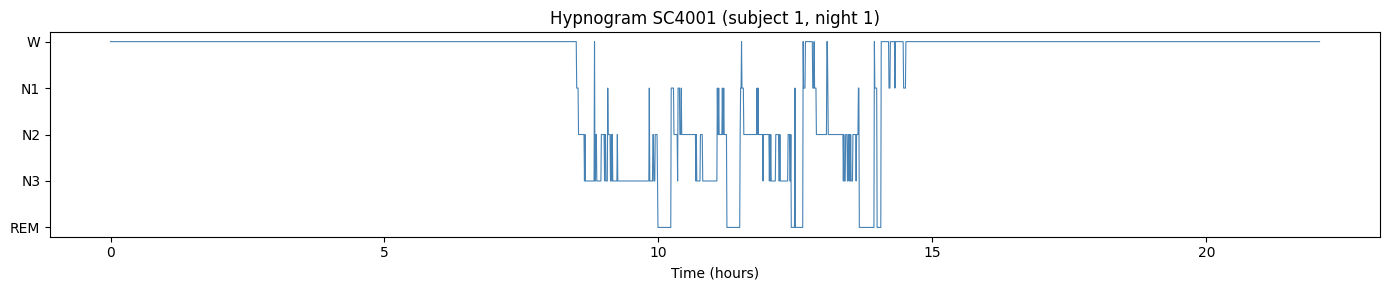


Epoch counts per stage:
  W: 1996 epochs  (998.0 min)
  N1: 58 epochs  (29.0 min)
  N2: 250 epochs  (125.0 min)
  N3: 220 epochs  (110.0 min)
  REM: 125 epochs  (62.5 min)


In [12]:
epoch_duration = 30
total_epochs = int(raw.times[-1] / epoch_duration)
labels = np.full(total_epochs, -1)  # fill with -1 (unknown)

for ann in annotations:
    onset_epoch  = int(ann['onset'] / epoch_duration)
    n_epochs     = int(ann['duration'] / epoch_duration)
    stage        = stage_map.get(ann['description'], -1)
    labels[onset_epoch : onset_epoch + n_epochs] = stage

# Plot
fig, ax = plt.subplots(figsize=(14, 3))
time_hours = np.arange(total_epochs) * epoch_duration / 3600

ax.plot(time_hours, labels, color='steelblue', linewidth=0.8)
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['W', 'N1', 'N2', 'N3', 'REM'])
ax.set_xlabel("Time (hours)")
ax.set_title("Hypnogram SC4001 (subject 1, night 1)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Label distribution
unique, counts = np.unique(labels[labels >= 0], return_counts=True)
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
print("\nEpoch counts per stage:")
for u, c in zip(unique, counts):
    print(f"  {stage_names[u]}: {c} epochs  ({c*30/60:.1f} min)")

**Important Notes from the hypnogram:**

- The **flat line** from hour 0 to nearly **hour 8.5** is that long Wake period.

- Sleep starts around **hour 8.5** and ends around **hour 15**.  About 6.5 hours of actual sleep.

- You can see the **cycling pattern**. The brain goes deep (N2 to N3) then comes back up to REM, repeating every ~90 minutes. This is normal healthy sleep architecture.

**From Epoch Counts:**
- There is **class imbalance**.
- And if we train as this as is, the model will just learn to predict Wake (W) all the time.


#### Extract the Fpz-Cz channel only

Total samples: 7950000
Total epochs: 2650


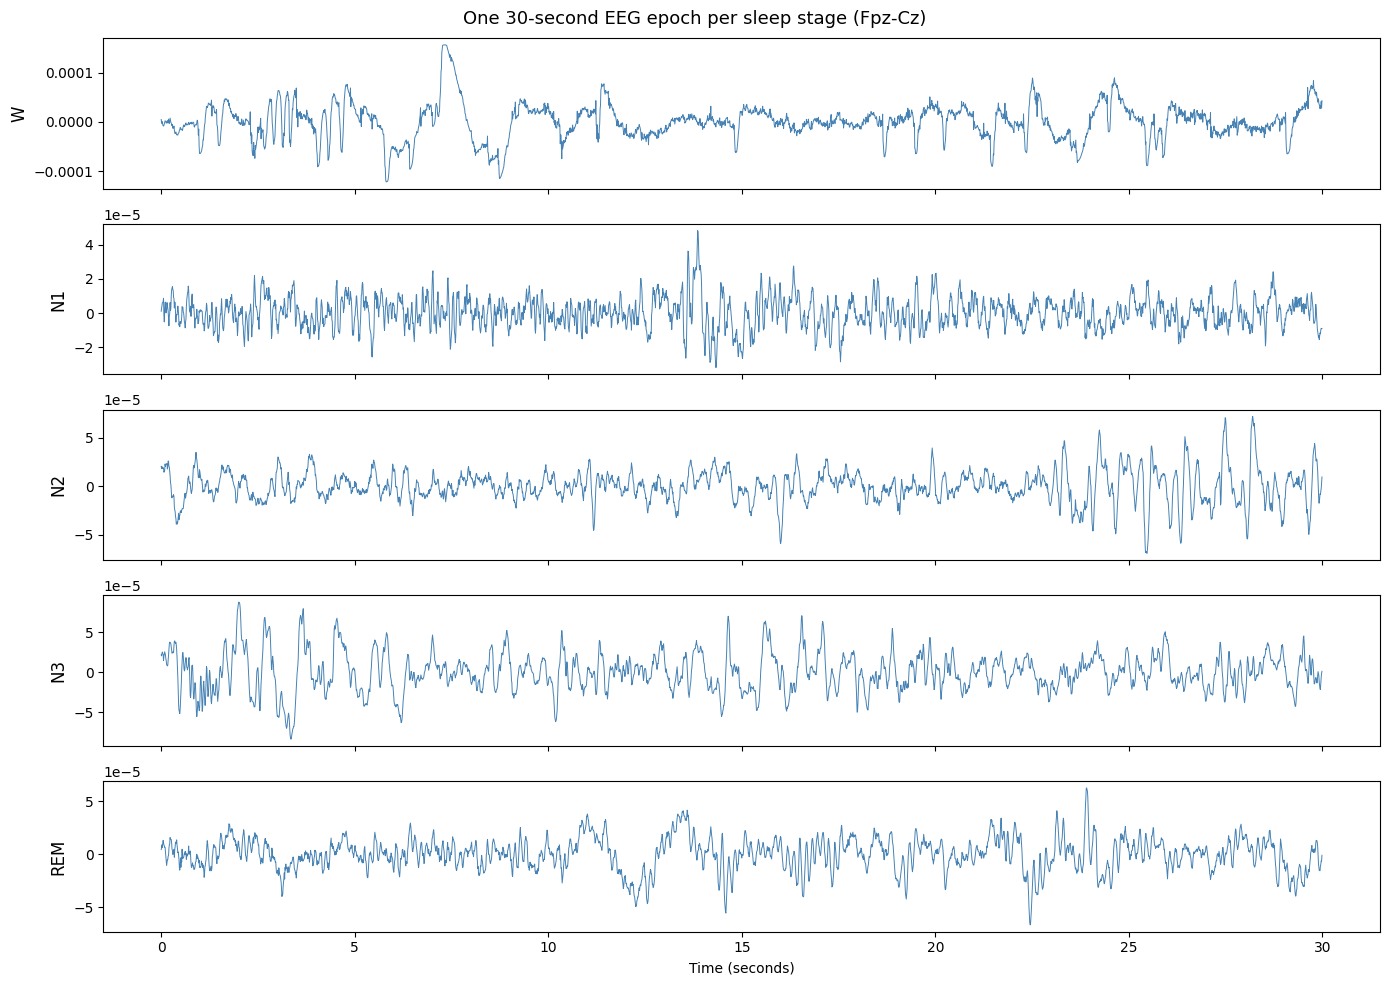

W: min=-0.000122, max=0.000157
N1: min=-0.000032, max=0.000048
N2: min=-0.000069, max=0.000072
N3: min=-0.000084, max=0.000088
REM: min=-0.000066, max=0.000062


In [13]:
raw_fpz = raw.copy().pick(['EEG Fpz-Cz'])
data, times = raw_fpz[:]   # shape: (1, total_samples)
data = data[0]             # flatten to 1D

print("Total samples:", len(data))
print("Total epochs:", len(data) // 3000)

# Pick one epoch from each stage to visualize
# Find first epoch of each stage
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

for stage_id in range(5):
    epoch_idx = np.where(labels == stage_id)[0][0]
    start_sample = epoch_idx * 3000
    epoch_data = data[start_sample : start_sample + 3000]
    t = np.arange(3000) / 100

    axes[stage_id].plot(t, epoch_data, linewidth=0.7, color='steelblue')
    axes[stage_id].set_ylabel(stage_names[stage_id], fontsize=12)
    # Let matplotlib auto-scale each subplot individually
    axes[stage_id].autoscale(axis='y')

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle("One 30-second EEG epoch per sleep stage (Fpz-Cz)", fontsize=13)
plt.tight_layout()
plt.show()

# Also print the actual value range so we know the unit
for stage_id in range(5):
    epoch_idx = np.where(labels == stage_id)[0][0]
    epoch_data = data[epoch_idx*3000 : epoch_idx*3000 + 3000]
    print(f"{stage_names[stage_id]}: min={epoch_data.min():.6f}, max={epoch_data.max():.6f}")

**Notes:**

- **W (Wake):**
    - notice the scale is 1e-4, much larger amplitude than the others. Fast, irregular, high-energy signal.
    - The brain is very active.

- **N1:**
    - Scale drops to 1e-5. Slower, smaller waves.
    - The brain is starting to quiet down.

- **N2:**
    - Similar scale to N1 but you can see bursts of faster oscillations. Those are sleep spindles (12–15 Hz bursts).
    - The CNN will learn to detect these.

- **N3:**
    - large, slow, rolling waves. These are delta waves (0.5–4 Hz). Notice the waves are wider and taller.
    - Classic deep sleep.

- **REM:**
    - Looks similar to N1/N2 but with more irregular, mixed-frequency activity.
    - Hardest stage to distinguish visually.

**Notes:**

- The data is in **volts**.
- The paper and the standard practice work in **microvolts**, so we convert it.

In [14]:
# Convert to microvolts (multiply by 1e6)
data_uv = data * 1e6

# Verify the range now looks normal for EEG (should be roughly ±100 uV)
for stage_id in range(5):
    epoch_idx = np.where(labels == stage_id)[0][0]
    epoch_data = data_uv[epoch_idx*3000 : epoch_idx*3000 + 3000]
    print(f"{stage_names[stage_id]}: min={epoch_data.min():.1f} uV, max={epoch_data.max():.1f} uV")

W: min=-121.6 uV, max=156.6 uV
N1: min=-31.9 uV, max=48.2 uV
N2: min=-69.2 uV, max=72.3 uV
N3: min=-83.9 uV, max=87.9 uV
REM: min=-66.4 uV, max=62.4 uV


`load_subject`: is a function that will do everything we've done so far in one call.                                                   
    1. Load the PSG                                       
    2. Load the hypnogram                                       
    3. Convert to µV                                              
    4. Return clean epochs + labels.

In [15]:
def load_subject(psg_path, hyp_path):

    stage_map = {
        'Sleep stage W':  0,
        'Sleep stage 1':  1,
        'Sleep stage 2':  2,
        'Sleep stage 3':  3,
        'Sleep stage 4':  3,  # merge N3+N4
        'Sleep stage R':  4,
        'Sleep stage ?': -1,
        'Movement time': -1,
    }

    # Load raw signal → pick Fpz-Cz only → convert to uV
    raw = mne.io.read_raw_edf(psg_path, preload=True)
    raw.pick(['EEG Fpz-Cz'])
    data = raw.get_data()[0] * 1e6

    # Build label array (one label per 30s epoch)
    annotations = mne.read_annotations(hyp_path)
    total_epochs = len(data) // 3000
    labels = np.full(total_epochs, -1)

    for ann in annotations:
        onset_epoch = int(ann['onset'] / 30)
        n_epochs    = int(ann['duration'] / 30)
        stage       = stage_map.get(ann['description'], -1)
        labels[onset_epoch : onset_epoch + n_epochs] = stage

    # Trim Wake: keep only 30 min (60 epochs) before and after sleep
    sleep_epochs = np.where(labels > 0)[0]

    if len(sleep_epochs) == 0:
        print(f"  [warn] No sleep epochs found, skipping {psg_path}")
        return np.empty((0, 3000), dtype=np.float32), np.empty((0,), dtype=np.int32)

    sleep_start = sleep_epochs[0]
    sleep_end   = sleep_epochs[-1]

    trim_start = max(0, sleep_start - 60)
    trim_end   = min(total_epochs, sleep_end + 60 + 1)

    labels = labels[trim_start : trim_end]
    data   = data[trim_start * 3000 : trim_end * 3000]

    # Slice into epochs of 3000 samples
    n_epochs_trimmed = len(labels)
    epochs = data[: n_epochs_trimmed * 3000].reshape(n_epochs_trimmed, 3000)

    # Remove unknown/movement epochs
    valid  = labels >= 0
    epochs = epochs[valid]
    labels = labels[valid]

    return epochs, labels


# Test it on subject 1
epochs, labels = load_subject(
    os.path.join(DATA_DIR, "SC4001E0-PSG.edf"),
    glob.glob(os.path.join(DATA_DIR, "SC4001E*Hypnogram.edf"))[0]
)

stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
print("Epochs shape:", epochs.shape)
print("Labels shape:", labels.shape)
print("\nEpoch counts after trimming:")
for i, name in enumerate(stage_names):
    count = np.sum(labels == i)
    print(f"  {name}: {count} epochs  ({count*30/60:.1f} min)")

/tmp/ipykernel_21371/936496594.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
/tmp/ipykernel_21371/936496594.py:15: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
/tmp/ipykernel_21371/936496594.py:15: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


Epochs shape: (841, 3000)
Labels shape: (841,)

Epoch counts after trimming:
  W: 188 epochs  (94.0 min)
  N1: 58 epochs  (29.0 min)
  N2: 250 epochs  (125.0 min)
  N3: 220 epochs  (110.0 min)
  REM: 125 epochs  (62.5 min)


**Important Notes:**
- W dropped from **1996 to 187 epochs** (trimmed to ~30 min around sleep)
- All sleep stages are intact - N1, N2, N3, REM unchanged
- Total: **840 clean epochs** ready for training

- The imbalance is still there (W dominates) but it's much more manageable now.

- The paper handles the rest through oversampling during training.

In [16]:
# Find ALL PSG files and pair them with their hypnograms
psg_files = sorted(glob.glob(os.path.join(DATA_DIR, "*PSG.edf")))

print(f"Found {len(psg_files)} PSG files:")
for f in psg_files:
    print(" ", os.path.basename(f))

Found 153 PSG files:
  SC4001E0-PSG.edf
  SC4002E0-PSG.edf
  SC4011E0-PSG.edf
  SC4012E0-PSG.edf
  SC4021E0-PSG.edf
  SC4022E0-PSG.edf
  SC4031E0-PSG.edf
  SC4032E0-PSG.edf
  SC4041E0-PSG.edf
  SC4042E0-PSG.edf
  SC4051E0-PSG.edf
  SC4052E0-PSG.edf
  SC4061E0-PSG.edf
  SC4062E0-PSG.edf
  SC4071E0-PSG.edf
  SC4072E0-PSG.edf
  SC4081E0-PSG.edf
  SC4082E0-PSG.edf
  SC4091E0-PSG.edf
  SC4092E0-PSG.edf
  SC4101E0-PSG.edf
  SC4102E0-PSG.edf
  SC4111E0-PSG.edf
  SC4112E0-PSG.edf
  SC4121E0-PSG.edf
  SC4122E0-PSG.edf
  SC4131E0-PSG.edf
  SC4141E0-PSG.edf
  SC4142E0-PSG.edf
  SC4151E0-PSG.edf
  SC4152E0-PSG.edf
  SC4161E0-PSG.edf
  SC4162E0-PSG.edf
  SC4171E0-PSG.edf
  SC4172E0-PSG.edf
  SC4181E0-PSG.edf
  SC4182E0-PSG.edf
  SC4191E0-PSG.edf
  SC4192E0-PSG.edf
  SC4201E0-PSG.edf
  SC4202E0-PSG.edf
  SC4211E0-PSG.edf
  SC4212E0-PSG.edf
  SC4221E0-PSG.edf
  SC4222E0-PSG.edf
  SC4231E0-PSG.edf
  SC4232E0-PSG.edf
  SC4241E0-PSG.edf
  SC4242E0-PSG.edf
  SC4251E0-PSG.edf
  SC4252E0-PSG.edf
  SC4261F0

- That's the full Sleep Cassette dataset.
- The paper uses **only the first 20 subjects** (SC40 series, subjects 01–20). So, I will filter to those.

#### Process each subject, and save everything to disk.

In [17]:
PROCESSED_DIR = "/content/drive/MyDrive/Queens_notebooks/processed/"
os.makedirs(PROCESSED_DIR, exist_ok=True)

for psg_path in psg_files:
    basename   = os.path.basename(psg_path)       # e.g. SC4001E0-PSG.edf
    subject_id = basename[:7]                      # e.g. SC4001E
    save_path  = os.path.join(PROCESSED_DIR, f"{subject_id}.npz")

    if os.path.exists(save_path):
        print(f"  Already done: {subject_id}")
        continue

    hyp_candidates = glob.glob(os.path.join(DATA_DIR, f"{subject_id}*Hypnogram.edf"))
    if not hyp_candidates:
        print(f"  WARNING: no hypnogram found for {subject_id}, skipping")
        continue

    hyp_path = hyp_candidates[0]
    print(f"Processing {subject_id} ...", end=" ", flush=True)
    epochs, labels = load_subject(psg_path, hyp_path)

    if len(epochs) == 0:
        print("0 epochs — skipping")
        continue

    np.savez_compressed(save_path, epochs=epochs, labels=labels)
    print(f"saved → {epochs.shape[0]} epochs")

print("\nAll done!")

  Already done: SC4001E
  Already done: SC4002E
  Already done: SC4011E
  Already done: SC4012E
  Already done: SC4021E
  Already done: SC4022E
  Already done: SC4031E
  Already done: SC4032E
  Already done: SC4041E
  Already done: SC4042E
  Already done: SC4051E
  Already done: SC4052E
  Already done: SC4061E
  Already done: SC4062E
  Already done: SC4071E
  Already done: SC4072E
  Already done: SC4081E
  Already done: SC4082E
  Already done: SC4091E
  Already done: SC4092E
  Already done: SC4101E
  Already done: SC4102E
  Already done: SC4111E
  Already done: SC4112E
  Already done: SC4121E
  Already done: SC4122E
  Already done: SC4131E
  Already done: SC4141E
  Already done: SC4142E
  Already done: SC4151E
  Already done: SC4152E
  Already done: SC4161E
  Already done: SC4162E
  Already done: SC4171E
  Already done: SC4172E
  Already done: SC4181E
  Already done: SC4182E
  Already done: SC4191E
  Already done: SC4192E
  Already done: SC4201E
  Already done: SC4202E
  Already done: 

In [18]:
all_npz = sorted(glob.glob(os.path.join(PROCESSED_DIR, "*.npz")))

bad_files = []
for f in all_npz:
    try:
        d = np.load(f)
        _ = d['labels']  # force actual read
    except (EOFError, Exception) as e:
        print(f"CORRUPTED: {os.path.basename(f)} — {e}")
        bad_files.append(f)

print(f"\nFound {len(bad_files)} corrupted file(s)")


Found 0 corrupted file(s)


In [19]:
for f in bad_files:
    basename   = os.path.basename(f).replace('.npz', '')   # e.g. SC4261F
    print(f"Deleting and reprocessing {basename}...")
    os.remove(f)

    psg_candidates = glob.glob(os.path.join(DATA_DIR, f"{basename}*PSG.edf"))
    hyp_candidates = glob.glob(os.path.join(DATA_DIR, f"{basename}*Hypnogram.edf"))

    if not psg_candidates or not hyp_candidates:
        print(f"  WARNING: missing EDF files for {basename}, skipping")
        continue

    epochs, labels = load_subject(psg_candidates[0], hyp_candidates[0])

    if len(epochs) == 0:
        print(f"  0 epochs — skipping")
        continue

    save_path = os.path.join(PROCESSED_DIR, f"{basename}.npz")
    np.savez_compressed(save_path, epochs=epochs, labels=labels)
    print(f"  Reprocessed → {epochs.shape[0]} epochs")

In [20]:
all_npz = sorted(glob.glob(os.path.join(PROCESSED_DIR, "*.npz")))

total_epochs    = 0
total_per_stage = np.zeros(5, dtype=int)
stage_names     = ['W', 'N1', 'N2', 'N3', 'REM']

print(f"{'Subject':<12} {'Total':>6}  {'W':>5} {'N1':>5} {'N2':>5} {'N3':>5} {'REM':>5}")
print("-" * 55)

for f in all_npz:
    d      = np.load(f)
    lbs    = d['labels']
    subj   = os.path.basename(f).replace('.npz', '')
    counts = [int(np.sum(lbs == i)) for i in range(5)]
    total_per_stage += counts
    total_epochs    += len(lbs)
    print(f"{subj:<12} {len(lbs):>6}  {counts[0]:>5} {counts[1]:>5} {counts[2]:>5} {counts[3]:>5} {counts[4]:>5}")

print("-" * 55)
print(f"{'TOTAL':<12} {total_epochs:>6}  {total_per_stage[0]:>5} {total_per_stage[1]:>5} {total_per_stage[2]:>5} {total_per_stage[3]:>5} {total_per_stage[4]:>5}")
print()
print("Class distribution (%):")
for i, name in enumerate(stage_names):
    pct = 100 * total_per_stage[i] / total_epochs
    print(f"  {name}: {pct:.1f}%")

Subject       Total      W    N1    N2    N3   REM
-------------------------------------------------------
SC4001E         841    188    58   250   220   125
SC4002E        1127    183    59   373   297   215
SC4011E        1103    157   109   562   105   170
SC4012E        1186    162    92   660    96   176
SC4021E        1025    128    94   545    95   163
SC4022E        1009    125   184   402   119   179
SC4031E         952    140    61   485    57   209
SC4032E         911    136    45   400   131   199
SC4041E        1235    200   166   620    53   196
SC4042E        1200    185   137   514    94   270
SC4051E         672    208    44   217   135    68
SC4052E        1246    222   114   616   114   180
SC4061E         843    142    56   407   136   102
SC4062E        1016    193    90   417   129   187
SC4071E         976    124    89   403   162   198
SC4072E        1273    407    84   392   222   168
SC4081E        1134    323    68   262   350   131
SC4082E        1054    144

**Important Notes:**

- **N1 is the hardest problem**
    - only 21,522 epochs out of 195,469 total (11.0%).
    - Some subjects have very few: SC4111E has only 13 N1 epochs, SC4091E has only 19.
    - The model will struggle most with this class.

- **N2 dominates sleep**
    - 69,132 epochs (35.4%). This is normal.
    - N2 is the most common sleep stage in healthy adults.

- **N3 is sparse in many subjects**
    - Only 6.7% overall (13,039 epochs).
    - Many subjects have 0 N3 epochs: SC4202E, SC4321E, SC4322E, SC4331F, SC4332F, SC4341F, SC4342F, SC4641E, SC4642E, SC4712E, SC4721E, SC4722E, SC4731E, SC4732E, SC4741E, SC4742E, SC4751E, SC4762E.
    - These are likely older subjects — N3 naturally diminishes with age.

- **W is higher than the prototype**
    - 65,941 epochs (33.7%), averaging ~431 per subject.
    - Several subjects have very high Wake counts: SC4731E (1,840), SC4762E (1,839), SC4472F (1,437), SC4651E (1,424).
    - These subjects had much longer wake periods around sleep even after trimming.
    - This is expected — the full dataset includes older subjects who sleep less efficiently.
    

**The dataset is ready.**                                    
- 195,469 clean epochs across 153 subjects, all saved as `.npz` files

# Train/Test split

In [21]:
# Load subject paths only - no data in memory yet
all_npz  = sorted(glob.glob(os.path.join(PROCESSED_DIR, "*.npz")))
subjects = [{'name': os.path.basename(f).replace('.npz', ''), 'path': f}
            for f in all_npz]

print(f"Total subjects: {len(subjects)}")

# 80/20 subject-level split
n_test         = int(len(subjects) * 0.2)   # 20% = nearly 30 subjects
test_subjects  = subjects[:n_test]
train_subjects = subjects[n_test:]

print(f"Train: {len(train_subjects)} subjects")
print(f"Test : {len(test_subjects)}  subjects")
print(f"\nTest subjects: {[s['name'] for s in test_subjects]}")

Total subjects: 153
Train: 123 subjects
Test : 30  subjects

Test subjects: ['SC4001E', 'SC4002E', 'SC4011E', 'SC4012E', 'SC4021E', 'SC4022E', 'SC4031E', 'SC4032E', 'SC4041E', 'SC4042E', 'SC4051E', 'SC4052E', 'SC4061E', 'SC4062E', 'SC4071E', 'SC4072E', 'SC4081E', 'SC4082E', 'SC4091E', 'SC4092E', 'SC4101E', 'SC4102E', 'SC4111E', 'SC4112E', 'SC4121E', 'SC4122E', 'SC4131E', 'SC4141E', 'SC4142E', 'SC4151E']


**The approach is subject-level 80/20 split**

- **Test:** first 20 subjects (≈ 20% of data)
- **Train:** remaining 82 subjects (≈ 80% of data)
- This ensures no subject appears in both train and test (subject-disjoint),
  so the model is evaluated on completely unseen individuals.

In [22]:
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
N_EPOCHS    = 30
N_FOLDS     = 5

# Use 40 subjects for trial - change to train_subjects for final run
TRIAL_SUBJECTS = train_subjects

print("Device      :", DEVICE)
print("Train subjects (trial):", len(TRIAL_SUBJECTS))
print("Test  subjects        :", len(test_subjects))

Device      : cuda
Train subjects (trial): 123
Test  subjects        : 30


### Dataset Class

In [23]:
class SleepDataset(Dataset):
    """Loads subjects into memory in one shot — labels only for indexing."""
    def __init__(self, subject_list):
        epochs_list, labels_list = [], []
        for s in subject_list:
            d = np.load(s['path'])
            epochs_list.append(d['epochs'].astype(np.float32))
            labels_list.append(d['labels'].astype(np.int64))
            d.close()
        self.epochs = np.concatenate(epochs_list)
        self.labels = np.concatenate(labels_list)
        del epochs_list, labels_list
        gc.collect()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.FloatTensor(self.epochs[idx]).unsqueeze(0),
                int(self.labels[idx]))

# Build the CNN Model

#### Pre-training

In [24]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, pool_size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size,
                      stride=stride, padding=kernel_size//2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(pool_size),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        return self.block(x)


class TwoStreamCNN(nn.Module):
    def __init__(self, n_classes=5, Fs=100):
        super().__init__()

        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs//2,  stride=Fs//16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )

        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs*4, stride=Fs//2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        small    = self.cnn_small(x)
        large    = self.cnn_large(x)
        combined = torch.cat([small, large], dim=1)
        return self.classifier(combined)


# Sanity check
model  = TwoStreamCNN()
dummy  = torch.zeros(32, 1, 3000)
out    = model(dummy)
print("Output shape:", out.shape)   # should be (32, 5)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Output shape: torch.Size([32, 5])
Total parameters: 519,941


### K-Fold Training Loop

In [24]:
kf              = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results    = []
fold_histories  = []
fold_val_preds  = []   # store (all_preds, all_true) per fold for full metrics

for fold, (tr_idx, val_idx) in enumerate(kf.split(range(len(TRIAL_SUBJECTS))), 1):

    print(f"\n{'='*55}")
    print(f"Fold {fold}/{N_FOLDS} | {len(tr_idx)} train | {len(val_idx)} val subjects")
    print(f"{'='*55}")

    tr_dataset  = SleepDataset([TRIAL_SUBJECTS[i] for i in tr_idx])
    val_dataset = SleepDataset([TRIAL_SUBJECTS[i] for i in val_idx])
    print(f"  Train: {len(tr_dataset):,} epochs | Val: {len(val_dataset):,} epochs")

    tr_loader  = DataLoader(tr_dataset,  batch_size=128, shuffle=True,
                            pin_memory=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False,
                            pin_memory=True, num_workers=2)

    fold_model = TwoStreamCNN().to(DEVICE)
    optimizer  = torch.optim.Adam(fold_model.parameters(), lr=1e-4)
    criterion  = nn.CrossEntropyLoss()
    history    = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, N_EPOCHS + 1):

        # Train
        fold_model.train()
        tr_loss, correct, total = 0.0, 0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out  = fold_model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()
            correct += (out.argmax(1) == y_b).sum().item()
            total   += len(y_b)

        train_loss = tr_loss / len(tr_loader)
        train_acc  = 100 * correct / total

        # Validate
        fold_model.eval()
        val_loss_total         = 0.0
        all_preds, all_true    = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out       = fold_model(X_b)
                val_loss_total += criterion(out, y_b).item()
                all_preds.extend(out.argmax(1).cpu().numpy())
                all_true.extend(y_b.cpu().numpy())

        val_loss = val_loss_total / len(val_loader)
        val_acc  = 100 * np.mean(np.array(all_preds) == np.array(all_true))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:2d}/{N_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.1f}% | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.1f}%")

    # Fold metrics
    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    acc   = 100 * (all_preds == all_true).mean()
    mf1   = f1_score(all_true, all_preds, average='macro') * 100
    kappa = cohen_kappa_score(all_true, all_preds)
    print(f"\n  Fold {fold} → Acc: {acc:.2f}%  MF1: {mf1:.2f}%  κ: {kappa:.4f}")

    fold_results.append({'fold': fold, 'acc': acc, 'mf1': mf1, 'kappa': kappa})
    fold_histories.append(history)
    fold_val_preds.append((all_preds, all_true))

    # Save every fold model individually
    fold_path = os.path.join(PROCESSED_DIR, f"cnn_fold_{fold}.pth")
    torch.save(fold_model.state_dict(), fold_path)
    print(f"  Saved Fold {fold} model → {fold_path}")

    del tr_dataset, val_dataset, fold_model, tr_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()


Fold 1/5 | 98 train | 25 val subjects
  Train: 130,350 epochs | Val: 34,189 epochs
  Epoch 10/30 | Train Loss: 0.5995  Acc: 76.5% | Val Loss: 0.6818  Acc: 78.9%
  Epoch 20/30 | Train Loss: 0.5652  Acc: 78.0% | Val Loss: 0.6131  Acc: 80.0%
  Epoch 30/30 | Train Loss: 0.5460  Acc: 78.6% | Val Loss: 0.5946  Acc: 80.4%

  Fold 1 → Acc: 80.35%  MF1: 71.13%  κ: 0.7218
  Saved Fold 1 model → /content/drive/MyDrive/Queens_notebooks/processed/cnn_fold_1.pth

Fold 2/5 | 98 train | 25 val subjects
  Train: 133,352 epochs | Val: 31,187 epochs
  Epoch 10/30 | Train Loss: 0.5992  Acc: 76.6% | Val Loss: 0.6916  Acc: 78.4%
  Epoch 20/30 | Train Loss: 0.5637  Acc: 78.0% | Val Loss: 0.6288  Acc: 79.3%
  Epoch 30/30 | Train Loss: 0.5435  Acc: 78.8% | Val Loss: 0.6160  Acc: 79.7%

  Fold 2 → Acc: 79.73%  MF1: 69.88%  κ: 0.7100
  Saved Fold 2 model → /content/drive/MyDrive/Queens_notebooks/processed/cnn_fold_2.pth

Fold 3/5 | 98 train | 25 val subjects
  Train: 130,451 epochs | Val: 34,088 epochs
  Epoch 

### Per-Fold Full Metrics


FOLD 1 — Validation Metrics
  Accuracy  : 80.35%
  Macro F1  : 71.13%
  Cohen's κ : 0.7218

              precision    recall  f1-score   support

           W       0.91      0.93      0.92     12972
          N1       0.42      0.22      0.29      3887
          N2       0.80      0.89      0.84     11278
          N3       0.86      0.76      0.81      2016
         REM       0.66      0.74      0.70      4036

    accuracy                           0.80     34189
   macro avg       0.73      0.71      0.71     34189
weighted avg       0.78      0.80      0.79     34189



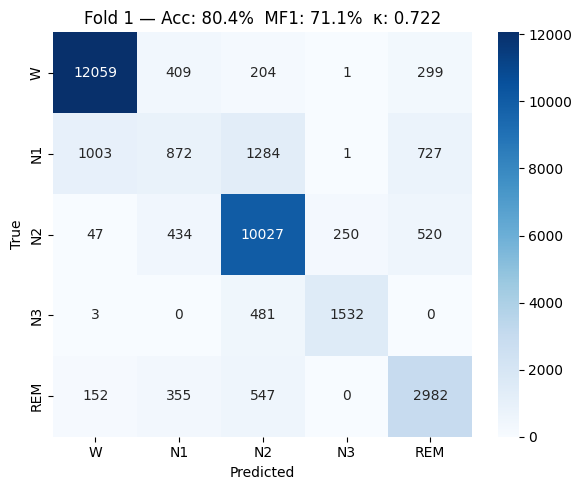


FOLD 2 — Validation Metrics
  Accuracy  : 79.73%
  Macro F1  : 69.88%
  Cohen's κ : 0.7100

              precision    recall  f1-score   support

           W       0.93      0.93      0.93     10593
          N1       0.50      0.25      0.33      3797
          N2       0.78      0.89      0.83     11767
          N3       0.67      0.76      0.71      1287
         REM       0.67      0.70      0.69      3743

    accuracy                           0.80     31187
   macro avg       0.71      0.71      0.70     31187
weighted avg       0.78      0.80      0.78     31187



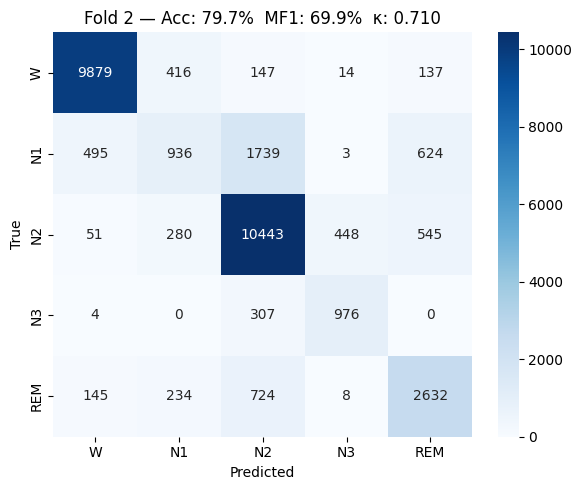


FOLD 3 — Validation Metrics
  Accuracy  : 79.99%
  Macro F1  : 70.25%
  Cohen's κ : 0.7146

              precision    recall  f1-score   support

           W       0.92      0.94      0.93     12270
          N1       0.46      0.20      0.28      4046
          N2       0.78      0.91      0.84     11863
          N3       0.80      0.79      0.79      1514
         REM       0.67      0.68      0.68      4395

    accuracy                           0.80     34088
   macro avg       0.73      0.70      0.70     34088
weighted avg       0.78      0.80      0.78     34088



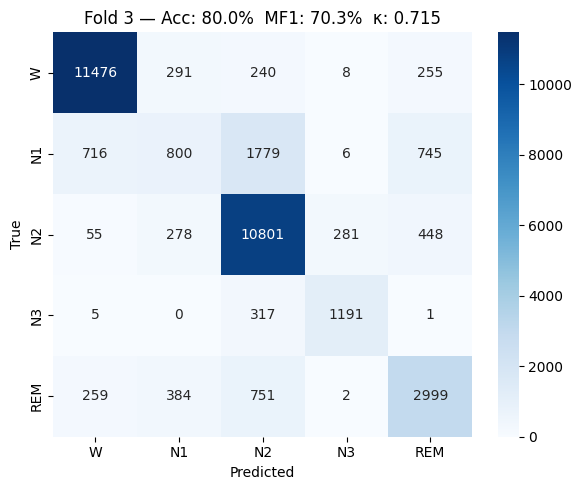


FOLD 4 — Validation Metrics
  Accuracy  : 76.07%
  Macro F1  : 66.79%
  Cohen's κ : 0.6635

              precision    recall  f1-score   support

           W       0.93      0.87      0.90     13127
          N1       0.35      0.28      0.31      3917
          N2       0.72      0.90      0.80      9981
          N3       0.82      0.61      0.70      2035
         REM       0.66      0.60      0.63      4024

    accuracy                           0.76     33084
   macro avg       0.70      0.65      0.67     33084
weighted avg       0.76      0.76      0.75     33084



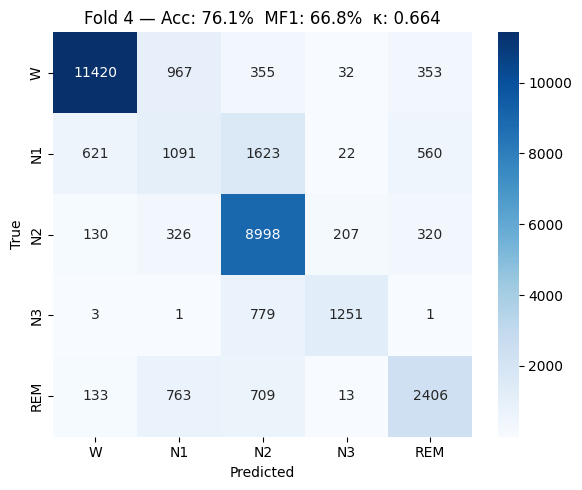


FOLD 5 — Validation Metrics
  Accuracy  : 75.54%
  Macro F1  : 65.32%
  Cohen's κ : 0.6572

              precision    recall  f1-score   support

           W       0.93      0.91      0.92     11611
          N1       0.29      0.21      0.24      3650
          N2       0.74      0.84      0.79     10749
          N3       0.78      0.66      0.72      2035
         REM       0.59      0.61      0.60      3946

    accuracy                           0.76     31991
   macro avg       0.67      0.65      0.65     31991
weighted avg       0.74      0.76      0.75     31991



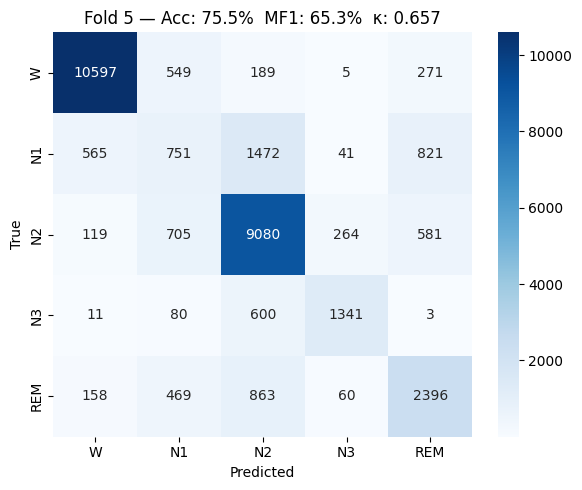

In [25]:
# Per-fold: full metrics, classification report, and confusion matrix

for fold_idx, (preds, trues) in enumerate(fold_val_preds, 1):
    acc_f   = 100 * (preds == trues).mean()
    mf1_f   = f1_score(trues, preds, average='macro') * 100
    kappa_f = cohen_kappa_score(trues, preds)

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx} — Validation Metrics")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc_f:.2f}%")
    print(f"  Macro F1  : {mf1_f:.2f}%")
    print(f"  Cohen's κ : {kappa_f:.4f}")
    print()
    print(classification_report(trues, preds, target_names=stage_names))

    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=stage_names, yticklabels=stage_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Fold {fold_idx} — Acc: {acc_f:.1f}%  MF1: {mf1_f:.1f}%  κ: {kappa_f:.3f}")
    plt.tight_layout()
    plt.show()

### CV Summary + Average-Based Model Selection

In [26]:
print(f"\n{'='*50}")
print("5-Fold CV Summary")
print(f"{'='*50}")
print(f"{'Fold':<8} {'Acc':>8} {'MF1':>8} {'κ':>8}")
print("-" * 38)
for r in fold_results:
    print(f"  {r['fold']:<6} {r['acc']:>7.2f}% {r['mf1']:>7.2f}% {r['kappa']:>8.4f}")
print("-" * 38)
accs   = [r['acc']   for r in fold_results]
mf1s   = [r['mf1']   for r in fold_results]
kappas = [r['kappa'] for r in fold_results]
mean_mf1 = np.mean(mf1s)
print(f"  {'Mean':<6} {np.mean(accs):>7.2f}% {mean_mf1:>7.2f}% {np.mean(kappas):>8.4f}")
print(f"  {'Std':<6} {np.std(accs):>7.2f}% {np.std(mf1s):>7.2f}% {np.std(kappas):>8.4f}")

# Select the fold whose MF1 is closest to the mean MF1
avg_fold_idx = int(np.argmin([abs(m - mean_mf1) for m in mf1s]))
best_fold    = fold_results[avg_fold_idx]['fold']
best_model_path = os.path.join(PROCESSED_DIR, f"cnn_fold_{best_fold}.pth")

print(f"\n  Selected representative fold (closest to mean MF1): "
      f"Fold {best_fold}  (MF1: {mf1s[avg_fold_idx]:.2f}%  |  Mean: {mean_mf1:.2f}%)")


5-Fold CV Summary
Fold          Acc      MF1        κ
--------------------------------------
  1        80.35%   71.13%   0.7218
  2        79.73%   69.88%   0.7100
  3        79.99%   70.25%   0.7146
  4        76.07%   66.79%   0.6635
  5        75.54%   65.32%   0.6572
--------------------------------------
  Mean     78.34%   68.67%   0.6934
  Std       2.09%    2.23%   0.0273

  Selected representative fold (closest to mean MF1): Fold 2  (MF1: 69.88%  |  Mean: 68.67%)


### Loss Curves: Per-Fold + Average

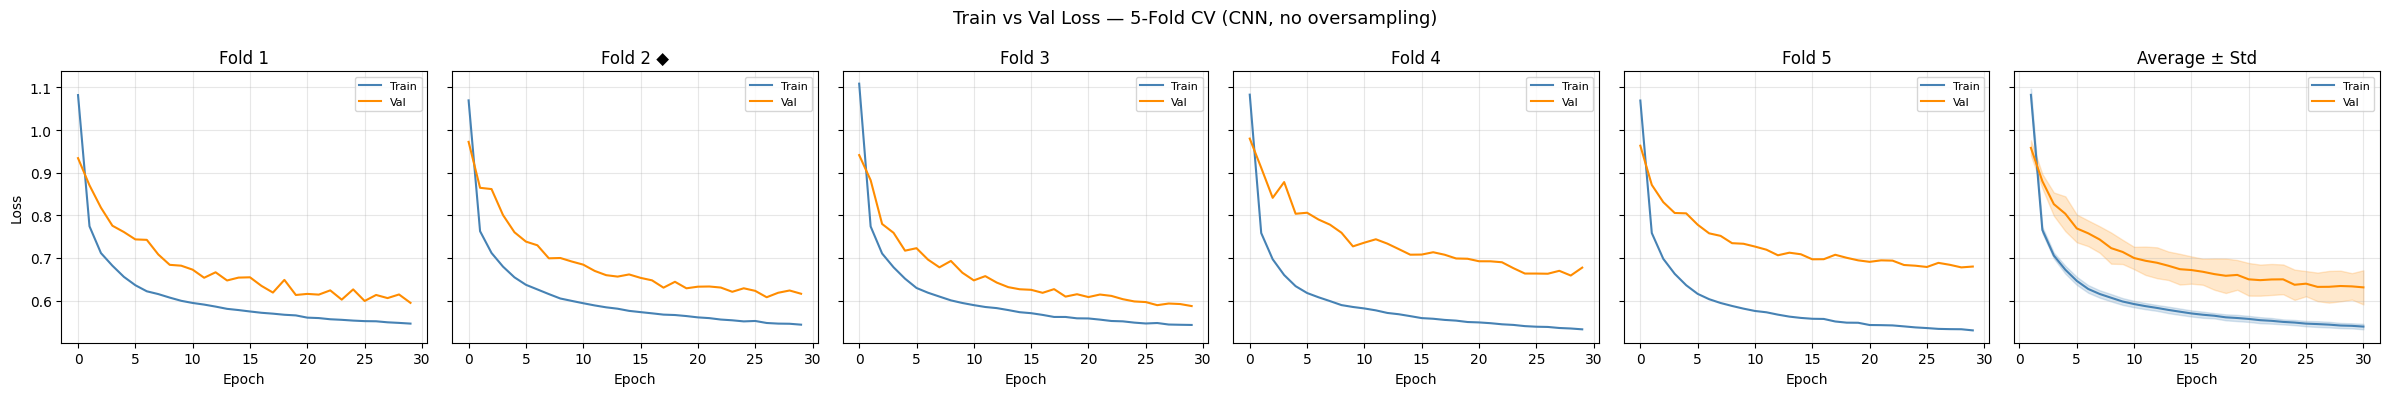

In [27]:
# Per-fold loss curves + average curve
n_plots = N_FOLDS + 1   # one panel per fold + one for the average
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)

for i, (ax, h) in enumerate(zip(axes[:N_FOLDS], fold_histories)):
    ax.plot(h['train_loss'], label='Train', color='steelblue')
    ax.plot(h['val_loss'],   label='Val',   color='darkorange')
    marker = ' ◆' if i + 1 == best_fold else ''
    ax.set_title(f'Fold {i+1}{marker}')
    ax.set_xlabel('Epoch')
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Average ± std panel
ax_avg = axes[-1]
train_matrix = np.array([h['train_loss'] for h in fold_histories])
val_matrix   = np.array([h['val_loss']   for h in fold_histories])
epochs_range = np.arange(1, N_EPOCHS + 1)

for matrix, color, label in [
    (train_matrix, 'steelblue',  'Train'),
    (val_matrix,   'darkorange', 'Val'),
]:
    mean_ = matrix.mean(axis=0)
    std_  = matrix.std(axis=0)
    ax_avg.plot(epochs_range, mean_, color=color, label=label)
    ax_avg.fill_between(epochs_range, mean_ - std_, mean_ + std_,
                        alpha=0.2, color=color)

ax_avg.set_title('Average ± Std')
ax_avg.set_xlabel('Epoch')
ax_avg.legend(fontsize=8)
ax_avg.grid(alpha=0.3)

fig.suptitle('Train vs Val Loss — 5-Fold CV (CNN, no oversampling)', fontsize=13)
plt.tight_layout()
plt.show()

Averaging weights across all 5 fold models...
Averaged weights loaded ✓

Retraining on full training data...
Full training epochs: 164,539
  Epoch  1/10 | Loss: 0.6961 | Acc: 72.9%
  Epoch  2/10 | Loss: 0.6080 | Acc: 76.2%
  Epoch  3/10 | Loss: 0.5862 | Acc: 77.1%
  Epoch  4/10 | Loss: 0.5748 | Acc: 77.6%
  Epoch  5/10 | Loss: 0.5678 | Acc: 77.9%
  Epoch  6/10 | Loss: 0.5614 | Acc: 78.0%
  Epoch  7/10 | Loss: 0.5569 | Acc: 78.3%
  Epoch  8/10 | Loss: 0.5530 | Acc: 78.4%
  Epoch  9/10 | Loss: 0.5505 | Acc: 78.5%
  Epoch 10/10 | Loss: 0.5465 | Acc: 78.7%

Final model saved → cnn_final_model.pth


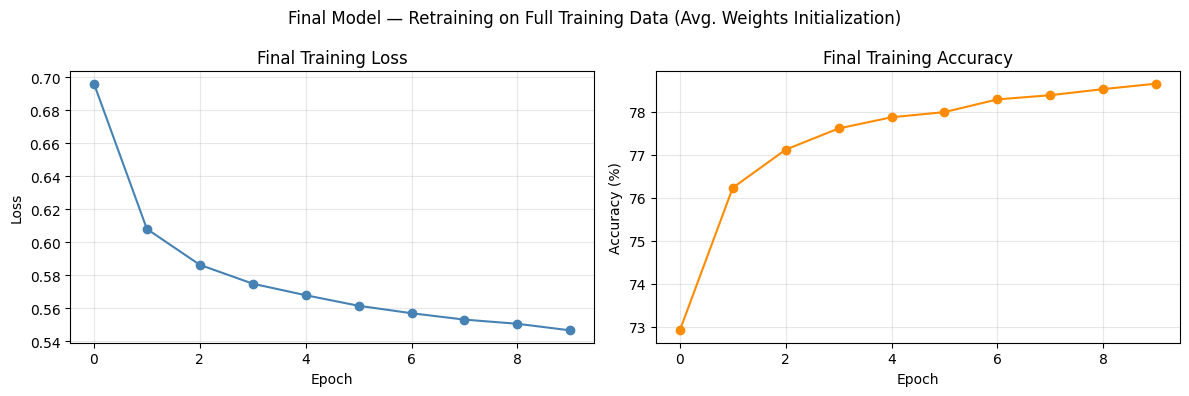


Evaluating on full training data (sanity check)...

Training Set Results — Final Model
Accuracy  : 80.62%
Macro F1  : 70.68%
Cohen's κ : 0.7251

              precision    recall  f1-score   support

           W       0.92      0.93      0.93     60573
          N1       0.50      0.18      0.27     19297
          N2       0.78      0.91      0.84     55638
          N3       0.83      0.76      0.79      8887
         REM       0.66      0.76      0.71     20144

    accuracy                           0.81    164539
   macro avg       0.74      0.71      0.71    164539
weighted avg       0.79      0.81      0.79    164539



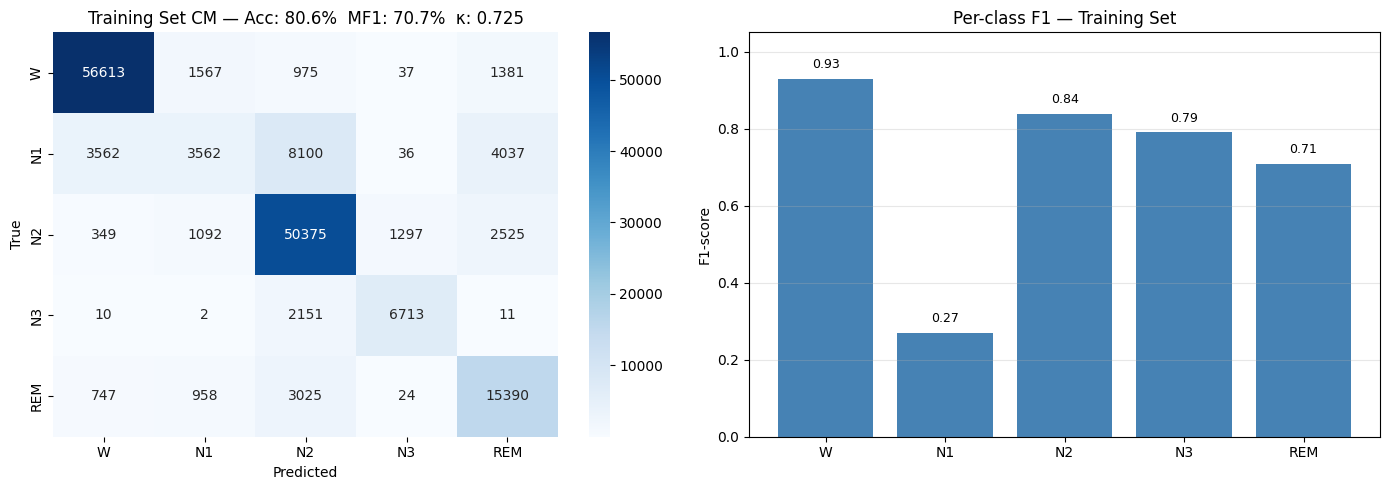

In [28]:
# Step 1: Average weights across all 5 fold models
print("Averaging weights across all 5 fold models...")

avg_state = {}
# Create a list to hold all state_dicts
all_state_dicts = []
for i in range(N_FOLDS):
    fold_path = os.path.join(PROCESSED_DIR, f"cnn_fold_{i+1}.pth")
    # Load each state_dict from file
    state_dict = torch.load(fold_path, map_location=DEVICE, weights_only=True)
    all_state_dicts.append(state_dict)

# Assuming all models have the same keys, use the first one to get keys
for key in all_state_dicts[0].keys():
    avg_state[key] = torch.stack(
        [state_dicts[key].float() for state_dicts in all_state_dicts]
    ).mean(dim=0)

# Load averaged weights into a fresh model
final_model = TwoStreamCNN().to(DEVICE)
final_model.load_state_dict(avg_state)
print("Averaged weights loaded ✓")

# Step 2: Retrain on ALL training subjects
print("\nRetraining on full training data...")

full_train_dataset = SleepDataset(train_subjects)
full_train_loader  = DataLoader(full_train_dataset, batch_size=256,
                                shuffle=True, pin_memory=True)
print(f"Full training epochs: {len(full_train_dataset):,}")

criterion      = nn.CrossEntropyLoss()
optimizer_final = torch.optim.Adam(final_model.parameters(), lr=1e-4)

N_FINAL_EPOCHS = 10   # short fine-tune since weights are already good
final_history  = {'train_loss': [], 'train_acc': []}

for epoch in range(1, N_FINAL_EPOCHS + 1):
    final_model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_b, y_b in full_train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_final.zero_grad()
        out  = final_model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer_final.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)

    train_loss = total_loss / len(full_train_loader)
    train_acc  = 100 * correct / total
    final_history['train_loss'].append(train_loss)
    final_history['train_acc'].append(train_acc)
    print(f"  Epoch {epoch:2d}/{N_FINAL_EPOCHS} | "
          f"Loss: {train_loss:.4f} | Acc: {train_acc:.1f}%")

# Save final model
final_model_path = os.path.join(PROCESSED_DIR, "cnn_final_model.pth")
torch.save(final_model.state_dict(), final_model_path)
print(f"\nFinal model saved → cnn_final_model.pth")

# Step 3: Plot final training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(final_history['train_loss'], color='steelblue', marker='o')
ax1.set_title('Final Training Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(final_history['train_acc'], color='darkorange', marker='o')
ax2.set_title('Final Training Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(alpha=0.3)

fig.suptitle('Final Model — Retraining on Full Training Data '
             '(Avg. Weights Initialization)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 4: Evaluate on training data
print("\nEvaluating on full training data (sanity check)...")
final_model.eval()
train_preds, train_true = [], []
with torch.no_grad():
    for X_b, y_b in full_train_loader:
        out = final_model(X_b.to(DEVICE))
        train_preds.extend(out.argmax(1).cpu().numpy())
        train_true.extend(y_b.numpy())

tr_pred = np.array(train_preds)
tr_true = np.array(train_true)

tr_acc   = 100 * (tr_pred == tr_true).mean()
tr_mf1   = f1_score(tr_true, tr_pred, average='macro') * 100
tr_kappa = cohen_kappa_score(tr_true, tr_pred)
tr_f1_pc = f1_score(tr_true, tr_pred, average=None, labels=list(range(5)))
tr_cm    = confusion_matrix(tr_true, tr_pred)

print(f"\nTraining Set Results — Final Model")
print(f"{'='*45}")
print(f"Accuracy  : {tr_acc:.2f}%")
print(f"Macro F1  : {tr_mf1:.2f}%")
print(f"Cohen's κ : {tr_kappa:.4f}")
print()
print(classification_report(tr_true, tr_pred, target_names=stage_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(tr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_title(f"Training Set CM — Acc: {tr_acc:.1f}%  MF1: {tr_mf1:.1f}%  κ: {tr_kappa:.3f}")

bars = ax2.bar(stage_names, tr_f1_pc, color='steelblue')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1 — Training Set')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tr_f1_pc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Test Evaluation

Final model loaded for test evaluation ✓
Test epochs: 30,930

Test Results — Final Model (Avg. Weights + Full Retrain)
Accuracy  : 82.32%
Macro F1  : 71.64%
Cohen's κ : 0.7508

              precision    recall  f1-score   support

           W       0.94      0.86      0.90      5368
          N1       0.46      0.11      0.17      2225
          N2       0.85      0.90      0.88     13494
          N3       0.88      0.92      0.90      4152
         REM       0.67      0.80      0.73      5691

    accuracy                           0.82     30930
   macro avg       0.76      0.72      0.72     30930
weighted avg       0.81      0.82      0.81     30930



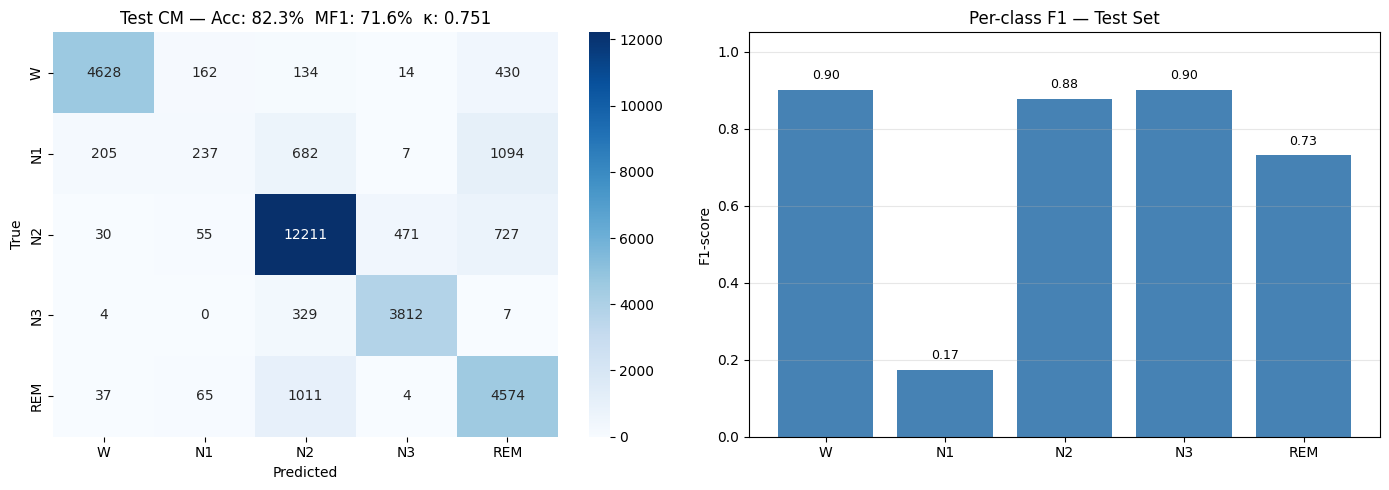

In [29]:
# Test evaluation
final_model.load_state_dict(
    torch.load(final_model_path, map_location=DEVICE, weights_only=True)
)
final_model.eval()
print("Final model loaded for test evaluation ✓")

test_dataset = SleepDataset(test_subjects)
test_loader  = DataLoader(test_dataset, batch_size=256,
                          shuffle=False, pin_memory=True)
print(f"Test epochs: {len(test_dataset):,}")

all_preds, all_true = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = final_model(X_b.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(y_b.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_true)

acc          = 100 * (y_pred == y_true).mean()
mf1          = f1_score(y_true, y_pred, average='macro') * 100
kappa        = cohen_kappa_score(y_true, y_pred)
f1_per_class = f1_score(y_true, y_pred, average=None, labels=list(range(5)))
cm           = confusion_matrix(y_true, y_pred)

print(f"\nTest Results — Final Model (Avg. Weights + Full Retrain)")
print(f"{'='*50}")
print(f"Accuracy  : {acc:.2f}%")
print(f"Macro F1  : {mf1:.2f}%")
print(f"Cohen's κ : {kappa:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=stage_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_title(f"Test CM — Acc: {acc:.1f}%  MF1: {mf1:.1f}%  κ: {kappa:.3f}")

bars = ax2.bar(stage_names, f1_per_class, color='steelblue')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1 — Test Set')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1_per_class):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Fine-Tuning with BiLSTM

#### CNN + BiLSTM Model (DeepSleepNet)

Stage-2 model: the pretrained CNN acts as a feature extractor for each epoch,
and the BiLSTM captures temporal dependencies across consecutive epochs.

**Architecture:**
- Same two-stream CNN as before (frozen or fine-tuned)
- 2-layer Bidirectional LSTM with residual shortcut
- Input: sequence of 25 consecutive epochs
- Output: one prediction per epoch in the sequence

In [ ]:
class DeepSleepNet(nn.Module):
    def __init__(self, n_classes=5, Fs=100):
        super().__init__()

        # --- Same two CNN streams as before ---
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs//2,  stride=Fs//16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )

        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs*4, stride=Fs//2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )

        # --- BiLSTM: takes sequence of CNN features ---
        # input size = 256 (128 small + 128 large)
        self.bilstm1 = nn.LSTM(input_size=256, hidden_size=512,
                               batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(input_size=1024, hidden_size=512,
                               batch_first=True, bidirectional=True)

        self.dropout = nn.Dropout(0.5)

        # Shortcut: projects CNN features (256) to match BiLSTM output (1024)
        self.shortcut = nn.Linear(256, 1024)

        # Final classifier
        self.classifier = nn.Linear(1024, n_classes)

    def extract_cnn_features(self, x):
        """Extract CNN features for a single epoch. x: (batch, 1, 3000)"""
        small    = self.cnn_small(x).squeeze(-1)   # (batch, 128)
        large    = self.cnn_large(x).squeeze(-1)   # (batch, 128)
        combined = torch.cat([small, large], dim=1) # (batch, 256)
        return combined

    def forward(self, x):
        """
        x shape: (batch, seq_len, 3000)
        seq_len = number of consecutive epochs fed as a sequence
        """
        batch, seq_len, signal_len = x.shape

        # Extract CNN features for every epoch in the sequence
        cnn_out = []
        for t in range(seq_len):
            feat = self.extract_cnn_features(x[:, t, :].unsqueeze(1))  # (batch, 256)
            cnn_out.append(feat)
        cnn_out = torch.stack(cnn_out, dim=1)   # (batch, seq_len, 256)

        # BiLSTM layers
        lstm_out, _ = self.bilstm1(cnn_out)              # (batch, seq_len, 1024)
        lstm_out     = self.dropout(lstm_out)
        lstm_out, _  = self.bilstm2(lstm_out)            # (batch, seq_len, 1024)
        lstm_out      = self.dropout(lstm_out)

        # Residual connection: add projected CNN features
        shortcut = self.shortcut(cnn_out)                # (batch, seq_len, 1024)
        out       = lstm_out + shortcut                  # (batch, seq_len, 1024)

        # Classify every epoch in the sequence
        out = self.classifier(out)                       # (batch, seq_len, 5)
        return out


# Test with a dummy sequence of 25 epochs
full_model = DeepSleepNet()
dummy_seq  = torch.zeros(4, 25, 3000)   # 4 batches, 25 epochs each
out        = full_model(dummy_seq)
print("Full model output shape:", out.shape)   # should be (4, 25, 5)
print(f"Total parameters: {sum(p.numel() for p in full_model.parameters()):,}")

Full model output shape: torch.Size([4, 25, 5])
Total parameters: 10,240,517


In [ ]:
# Load best CNN weights from Drive
pretrained     = torch.load(best_model_path, map_location=DEVICE, weights_only=True)
full_model     = DeepSleepNet().to(DEVICE)
full_model_dict = full_model.state_dict()

cnn_weights = {k: v for k, v in pretrained.items()
               if k.startswith('cnn_small') or k.startswith('cnn_large')}
full_model_dict.update(cnn_weights)
full_model.load_state_dict(full_model_dict)
print(f"Loaded {len(cnn_weights)} CNN weight tensors from pretrained model")

# Prepare sequential data
SEQ_LEN = 25

def make_sequences(epochs, labels, seq_len=25):
    """Slice subject data into consecutive sequences of seq_len epochs."""
    X_seqs, y_seqs = [], []
    n = len(labels)
    for start in range(0, n - seq_len + 1, seq_len):
        X_seqs.append(epochs[start : start + seq_len])
        y_seqs.append(labels[start : start + seq_len])
    return np.array(X_seqs), np.array(y_seqs)

# Build sequential training set — load from path
X_seq_list, y_seq_list = [], []
for s in TRIAL_SUBJECTS:           # use TRIAL_SUBJECTS to match the CNN trial
    d    = np.load(s['path'])
    X_s, y_s = make_sequences(d['epochs'], d['labels'], SEQ_LEN)
    X_seq_list.append(X_s)
    y_seq_list.append(y_s)
    d.close()

X_train_seq = np.concatenate(X_seq_list, axis=0)  # (n_seqs, 25, 3000)
y_train_seq = np.concatenate(y_seq_list, axis=0)  # (n_seqs, 25)
print(f"Training sequences : {X_train_seq.shape}")
print(f"Label sequences    : {y_train_seq.shape}")

# Build sequential test set — load from path
X_test_seq_list, y_test_seq_list = [], []
for s in test_subjects:
    d    = np.load(s['path'])
    X_s, y_s = make_sequences(d['epochs'], d['labels'], SEQ_LEN)
    X_test_seq_list.append(X_s)
    y_test_seq_list.append(y_s)
    d.close()

X_test_seq = np.concatenate(X_test_seq_list, axis=0)
y_test_seq = np.concatenate(y_test_seq_list, axis=0)
print(f"Test sequences     : {X_test_seq.shape}")

Loaded 42 CNN weight tensors from pretrained model
Training sequences : (1966, 25, 3000)
Label sequences    : (1966, 25)
Test sequences     : (1228, 25, 3000)


### BiLSTM Sequential Dataset

In [ ]:
class SeqSleepDataset(Dataset):
    """Dataset for sequential data (sequences of epochs)."""
    def __init__(self, X_seq, y_seq):
        self.X = X_seq.astype(np.float32)
        self.y = y_seq.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.LongTensor(self.y[idx])

### BiLSTM K-Fold Training Loop


Fold 1/5 | 1572 train seqs | 394 val seqs
  Epoch 10/30 | Train Loss: 0.4485  Acc: 83.3% | Val Loss: 0.5587  Acc: 80.1%
  Epoch 20/30 | Train Loss: 0.4284  Acc: 83.6% | Val Loss: 0.6231  Acc: 77.5%
  Epoch 30/30 | Train Loss: 0.4022  Acc: 84.3% | Val Loss: 0.5203  Acc: 80.9%

FOLD 1 — Validation Metrics  (CNN + BiLSTM)
  Accuracy  : 80.86%
  Macro F1  : 73.35%
  Cohen's κ : 0.7243

              precision    recall  f1-score   support

           W       0.98      0.87      0.92      2783
          N1       0.46      0.35      0.39       830
          N2       0.75      0.96      0.84      3960
          N3       0.89      0.71      0.79       675
         REM       0.88      0.62      0.73      1602

    accuracy                           0.81      9850
   macro avg       0.79      0.70      0.73      9850
weighted avg       0.82      0.81      0.80      9850



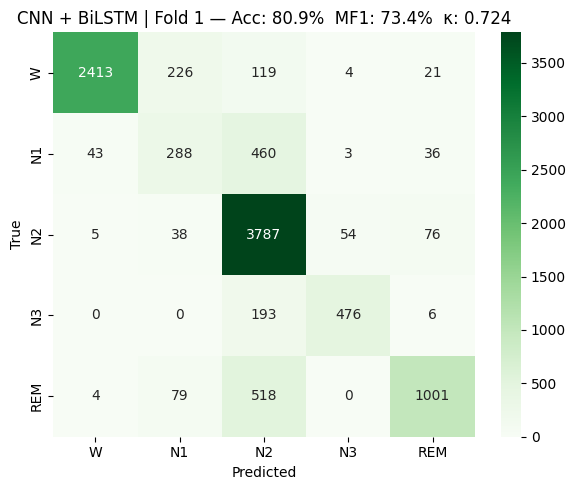

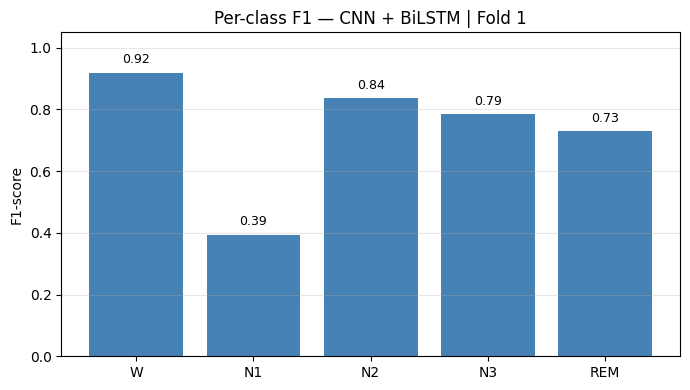


Fold 2/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4534  Acc: 82.8% | Val Loss: 0.7929  Acc: 70.1%
  Epoch 20/30 | Train Loss: 0.4093  Acc: 84.2% | Val Loss: 0.4908  Acc: 81.2%
  Epoch 30/30 | Train Loss: 0.3862  Acc: 85.0% | Val Loss: 0.4646  Acc: 81.4%

FOLD 2 — Validation Metrics  (CNN + BiLSTM)
  Accuracy  : 81.37%
  Macro F1  : 75.76%
  Cohen's κ : 0.7484

              precision    recall  f1-score   support

           W       0.94      0.92      0.93      2732
          N1       0.59      0.40      0.47      1005
          N2       0.90      0.78      0.83      3960
          N3       0.66      0.93      0.77       756
         REM       0.66      0.95      0.78      1372

    accuracy                           0.81      9825
   macro avg       0.75      0.80      0.76      9825
weighted avg       0.83      0.81      0.81      9825



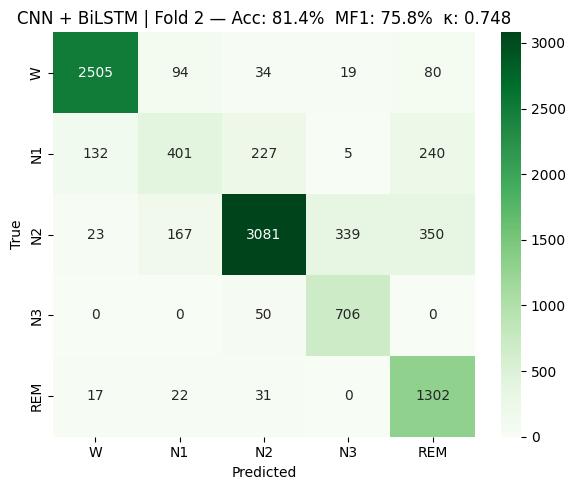

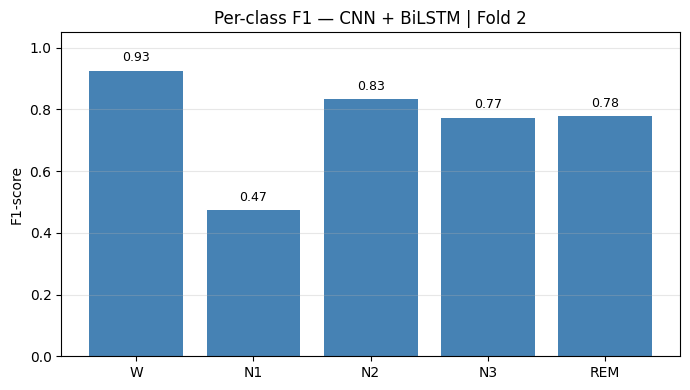


Fold 3/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4773  Acc: 81.8% | Val Loss: 0.5574  Acc: 80.2%
  Epoch 20/30 | Train Loss: 0.4272  Acc: 83.6% | Val Loss: 0.4334  Acc: 85.5%
  Epoch 30/30 | Train Loss: 0.4055  Acc: 84.4% | Val Loss: 0.7233  Acc: 74.0%

FOLD 3 — Validation Metrics  (CNN + BiLSTM)
  Accuracy  : 74.03%
  Macro F1  : 55.24%
  Cohen's κ : 0.6279

              precision    recall  f1-score   support

           W       0.99      0.74      0.84      3267
          N1       0.42      0.28      0.34       799
          N2       0.68      0.96      0.80      3597
          N3       0.76      0.03      0.06       734
         REM       0.66      0.81      0.73      1428

    accuracy                           0.74      9825
   macro avg       0.70      0.56      0.55      9825
weighted avg       0.76      0.74      0.71      9825



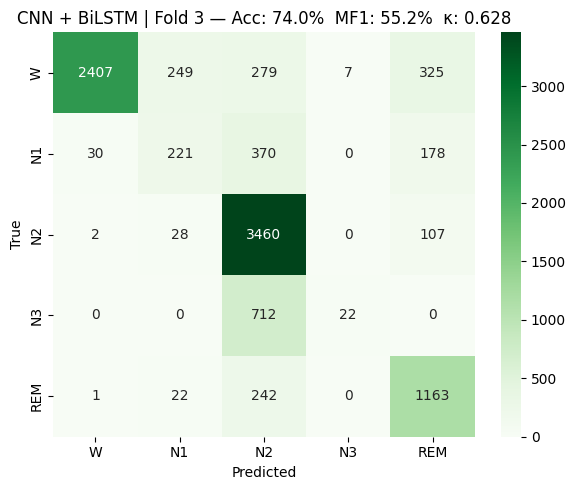

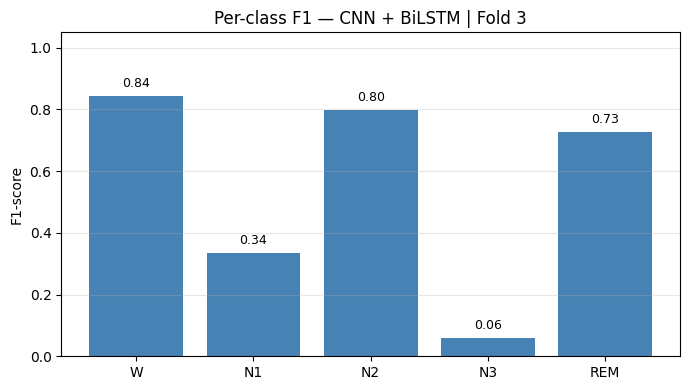


Fold 4/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4409  Acc: 82.9% | Val Loss: 0.5545  Acc: 80.7%
  Epoch 20/30 | Train Loss: 0.4260  Acc: 83.9% | Val Loss: 0.5199  Acc: 82.3%
  Epoch 30/30 | Train Loss: 0.4004  Acc: 84.3% | Val Loss: 0.5624  Acc: 79.2%

FOLD 4 — Validation Metrics  (CNN + BiLSTM)
  Accuracy  : 79.17%
  Macro F1  : 77.01%
  Cohen's κ : 0.7266

              precision    recall  f1-score   support

           W       0.95      0.90      0.92      2885
          N1       0.39      0.73      0.50      1047
          N2       0.88      0.72      0.79      3488
          N3       0.87      0.76      0.81       828
         REM       0.84      0.80      0.82      1577

    accuracy                           0.79      9825
   macro avg       0.78      0.78      0.77      9825
weighted avg       0.84      0.79      0.81      9825



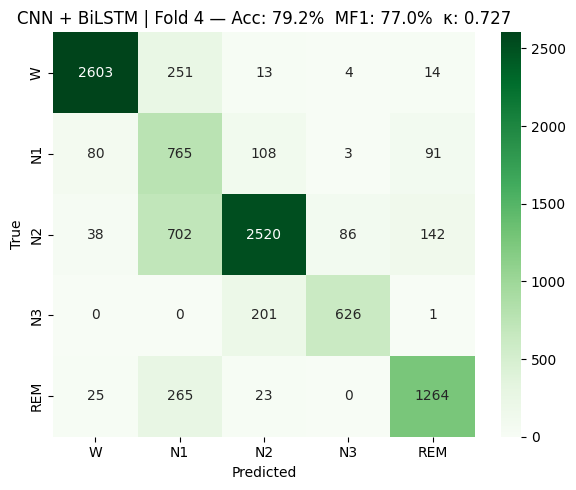

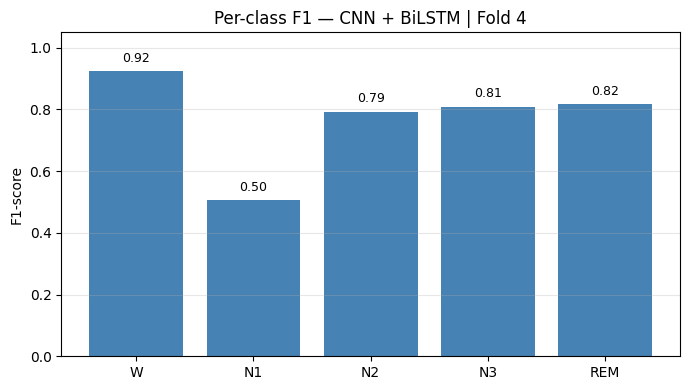


Fold 5/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4986  Acc: 81.4% | Val Loss: 0.7325  Acc: 72.3%
  Epoch 20/30 | Train Loss: 0.4255  Acc: 83.8% | Val Loss: 0.3939  Acc: 85.8%
  Epoch 30/30 | Train Loss: 0.3983  Acc: 84.6% | Val Loss: 0.4655  Acc: 83.3%

FOLD 5 — Validation Metrics  (CNN + BiLSTM)
  Accuracy  : 83.26%
  Macro F1  : 74.73%
  Cohen's κ : 0.7664

              precision    recall  f1-score   support

           W       0.96      0.90      0.93      3294
          N1       0.42      0.28      0.34       795
          N2       0.83      0.86      0.84      3654
          N3       0.66      0.96      0.79       571
         REM       0.82      0.85      0.84      1511

    accuracy                           0.83      9825
   macro avg       0.74      0.77      0.75      9825
weighted avg       0.83      0.83      0.83      9825



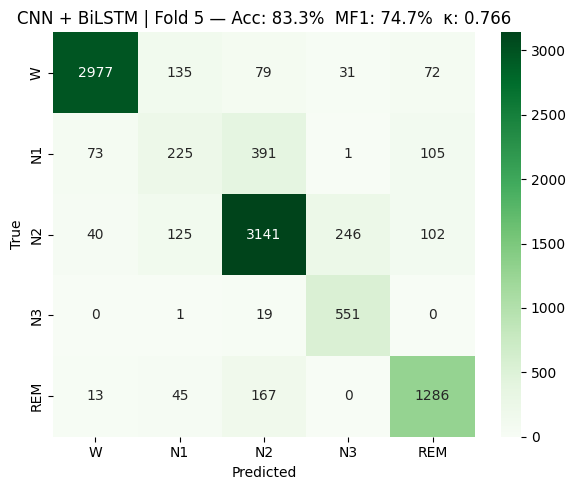

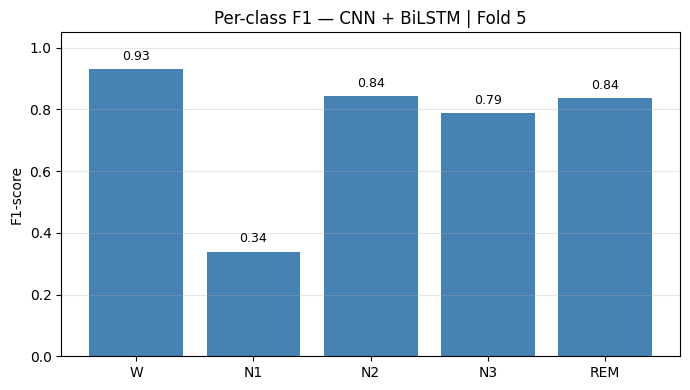

In [ ]:
kf_seq             = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
seq_fold_results   = []
seq_fold_histories = []

for fold, (tr_idx, val_idx) in enumerate(kf_seq.split(range(len(X_train_seq))), 1):

    print(f"\n{'='*55}")
    print(f"Fold {fold}/{N_FOLDS} | {len(tr_idx)} train seqs | {len(val_idx)} val seqs")
    print(f"{'='*55}")

    tr_dataset  = SeqSleepDataset(X_train_seq[tr_idx], y_train_seq[tr_idx])
    val_dataset = SeqSleepDataset(X_train_seq[val_idx], y_train_seq[val_idx])

    tr_loader  = DataLoader(tr_dataset,  batch_size=16, shuffle=True,  pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

    fold_model      = DeepSleepNet().to(DEVICE)
    fold_model_dict = fold_model.state_dict()
    fold_model_dict.update(cnn_weights)
    fold_model.load_state_dict(fold_model_dict)

    cnn_params  = (list(fold_model.cnn_small.parameters()) +
                   list(fold_model.cnn_large.parameters()))
    lstm_params = (list(fold_model.bilstm1.parameters())  +
                   list(fold_model.bilstm2.parameters())  +
                   list(fold_model.shortcut.parameters()) +
                   list(fold_model.classifier.parameters()))

    optimizer = torch.optim.Adam([
        {'params': cnn_params,  'lr': 1e-6},
        {'params': lstm_params, 'lr': 1e-4},
    ])
    criterion = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, N_EPOCHS + 1):

        # Train
        fold_model.train()
        tr_loss, correct, total = 0.0, 0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out      = fold_model(X_b)
            out_flat = out.view(-1, 5)
            y_flat   = y_b.view(-1)
            loss     = criterion(out_flat, y_flat)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=10)
            optimizer.step()
            tr_loss += loss.item()
            correct += (out_flat.argmax(1) == y_flat).sum().item()
            total   += len(y_flat)

        train_loss = tr_loss / len(tr_loader)
        train_acc  = 100 * correct / total

        # Validate
        fold_model.eval()
        val_loss_total      = 0.0
        all_preds, all_true = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out       = fold_model(X_b)
                out_flat  = out.view(-1, 5)
                y_flat    = y_b.view(-1)
                val_loss_total += criterion(out_flat, y_flat).item()
                all_preds.extend(out_flat.argmax(1).cpu().numpy())
                all_true.extend(y_flat.cpu().numpy())

        val_loss = val_loss_total / len(val_loader)
        val_acc  = 100 * np.mean(np.array(all_preds) == np.array(all_true))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:2d}/{N_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.1f}% | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.1f}%")

    # Fold metrics
    all_preds    = np.array(all_preds)
    all_true     = np.array(all_true)
    acc          = 100 * (all_preds == all_true).mean()
    mf1          = f1_score(all_true, all_preds, average='macro') * 100
    kappa        = cohen_kappa_score(all_true, all_preds)
    f1_per_class = f1_score(all_true, all_preds, average=None, labels=list(range(5)))
    cm           = confusion_matrix(all_true, all_preds)

    # Print fold metrics
    print(f"\n{'='*60}")
    print(f"FOLD {fold} — Validation Metrics  (CNN + BiLSTM)")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Macro F1  : {mf1:.2f}%")
    print(f"  Cohen's κ : {kappa:.4f}")
    print()
    print(classification_report(all_true, all_preds, target_names=stage_names))

    # Fold confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=stage_names, yticklabels=stage_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"CNN + BiLSTM | Fold {fold} — "
              f"Acc: {acc:.1f}%  MF1: {mf1:.1f}%  κ: {kappa:.3f}")
    plt.tight_layout()
    plt.show()

    # Fold per-class F1
    plt.figure(figsize=(7, 4))
    bars = plt.bar(stage_names, f1_per_class, color='steelblue')
    plt.ylabel('F1-score'); plt.ylim(0, 1.05)
    plt.title(f'Per-class F1 — CNN + BiLSTM | Fold {fold}')
    plt.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, f1_per_class):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Save fold model and state_dict
    fold_path = os.path.join(PROCESSED_DIR, f"bilstm_fold_{fold}.pth")
    torch.save(fold_model.state_dict(), fold_path)

    seq_fold_results.append({
        'fold'        : fold,
        'acc'         : acc,
        'mf1'         : mf1,
        'kappa'       : kappa,
        'f1_per_class': f1_per_class,
        'cm'          : cm,
        'model_path'  : fold_path,
        'state_dict'  : fold_model.state_dict(),
    })
    seq_fold_histories.append(history)

    del tr_dataset, val_dataset, fold_model, tr_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()

### CV Summary + Loss Plots


5-Fold CV Summary — CNN + BiLSTM
Fold          Acc      MF1        κ
--------------------------------------
  1        80.86%   73.35%   0.7243
  2        81.37%   75.76%   0.7484
  3        74.03%   55.24%   0.6279
  4        79.17%   77.01%   0.7266
  5        83.26%   74.73%   0.7664
--------------------------------------
  Mean     79.74%   71.22%   0.7187
  Std       3.14%    8.08%   0.0480

  Representative fold (closest to mean MF1): Fold 1  (MF1: 73.35%  |  Mean: 71.22%)


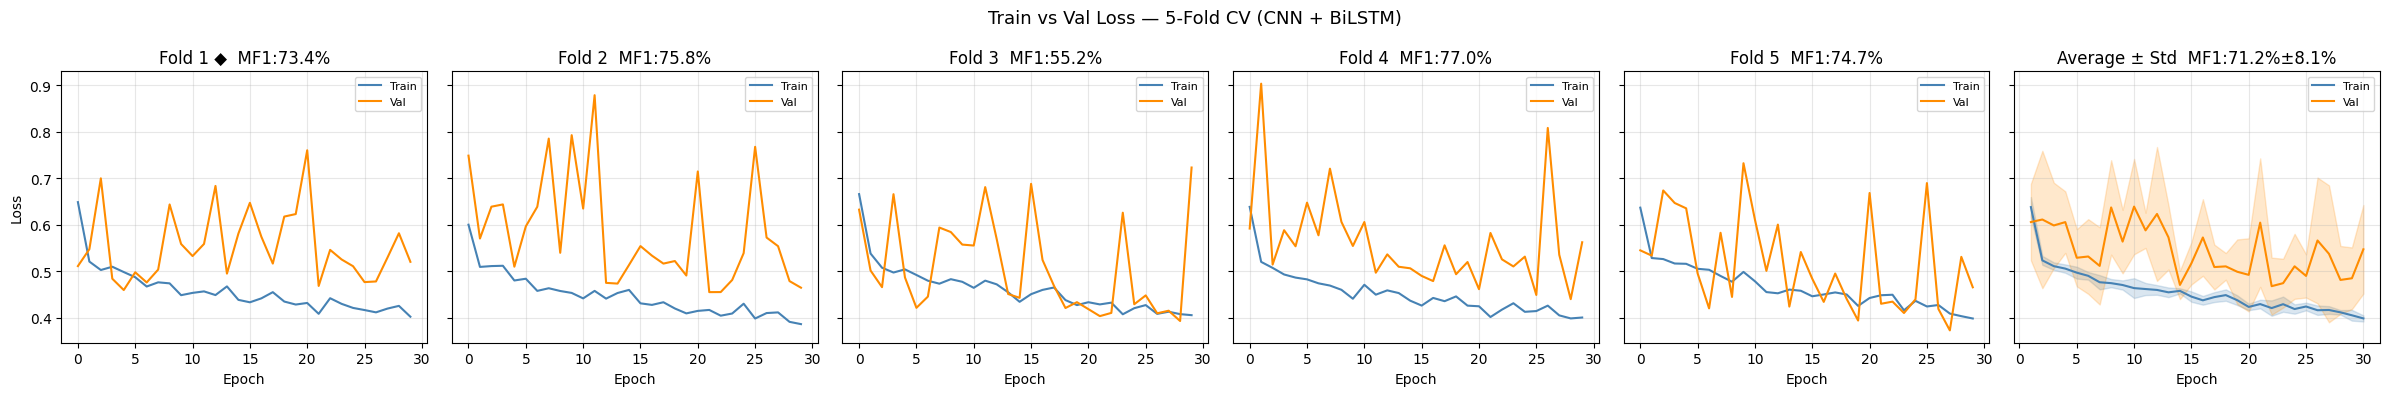

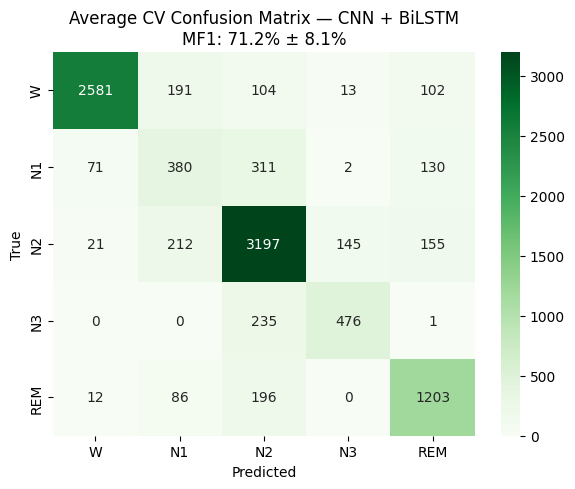

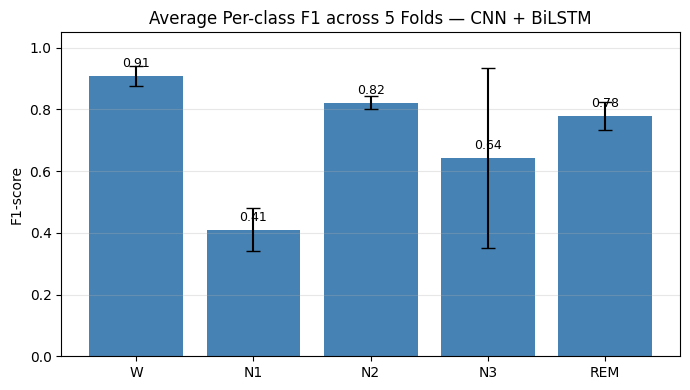

In [ ]:
print(f"\n{'='*50}")
print("5-Fold CV Summary — CNN + BiLSTM")
print(f"{'='*50}")
print(f"{'Fold':<8} {'Acc':>8} {'MF1':>8} {'κ':>8}")
print("-" * 38)
for r in seq_fold_results:
    print(f"  {r['fold']:<6} {r['acc']:>7.2f}% {r['mf1']:>7.2f}% {r['kappa']:>8.4f}")
print("-" * 38)
accs     = [r['acc']   for r in seq_fold_results]
mf1s     = [r['mf1']   for r in seq_fold_results]
kappas   = [r['kappa'] for r in seq_fold_results]
mean_mf1 = np.mean(mf1s)
print(f"  {'Mean':<6} {np.mean(accs):>7.2f}% {mean_mf1:>7.2f}% {np.mean(kappas):>8.4f}")
print(f"  {'Std':<6} {np.std(accs):>7.2f}% {np.std(mf1s):>7.2f}% {np.std(kappas):>8.4f}")

# Select representative fold (closest to mean MF1)
avg_fold_idx  = int(np.argmin([abs(m - mean_mf1) for m in mf1s]))
best_seq_fold = seq_fold_results[avg_fold_idx]['fold']
print(f"\n  Representative fold (closest to mean MF1): "
      f"Fold {best_seq_fold}  (MF1: {mf1s[avg_fold_idx]:.2f}%  |  Mean: {mean_mf1:.2f}%)")

# Per-fold loss curves + average panel
n_plots = N_FOLDS + 1
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)

for i, (ax, h) in enumerate(zip(axes[:N_FOLDS], seq_fold_histories)):
    ax.plot(h['train_loss'], label='Train', color='steelblue')
    ax.plot(h['val_loss'],   label='Val',   color='darkorange')
    marker = ' ◆' if i + 1 == best_seq_fold else ''
    ax.set_title(f'Fold {i+1}{marker}  MF1:{seq_fold_results[i]["mf1"]:.1f}%')
    ax.set_xlabel('Epoch')
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

ax_avg       = axes[-1]
train_matrix = np.array([h['train_loss'] for h in seq_fold_histories])
val_matrix   = np.array([h['val_loss']   for h in seq_fold_histories])
epochs_range = np.arange(1, N_EPOCHS + 1)

for matrix, color, label in [
    (train_matrix, 'steelblue',  'Train'),
    (val_matrix,   'darkorange', 'Val'),
]:
    mean_ = matrix.mean(axis=0)
    std_  = matrix.std(axis=0)
    ax_avg.plot(epochs_range, mean_, color=color, label=label)
    ax_avg.fill_between(epochs_range, mean_ - std_, mean_ + std_,
                        alpha=0.2, color=color)

ax_avg.set_title(f'Average ± Std  MF1:{mean_mf1:.1f}%±{np.std(mf1s):.1f}%')
ax_avg.set_xlabel('Epoch')
ax_avg.legend(fontsize=8)
ax_avg.grid(alpha=0.3)

fig.suptitle('Train vs Val Loss — 5-Fold CV (CNN + BiLSTM)', fontsize=13)
plt.tight_layout()
plt.show()

# Average confusion matrix across folds
avg_cm = np.mean([r['cm'] for r in seq_fold_results], axis=0).astype(int)
plt.figure(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=stage_names, yticklabels=stage_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Average CV Confusion Matrix — CNN + BiLSTM\n"
          f"MF1: {mean_mf1:.1f}% ± {np.std(mf1s):.1f}%")
plt.tight_layout()
plt.show()

# Average per-class F1 with error bars
avg_f1_pc = np.mean([r['f1_per_class'] for r in seq_fold_results], axis=0)
std_f1_pc = np.std( [r['f1_per_class'] for r in seq_fold_results], axis=0)

plt.figure(figsize=(7, 4))
bars = plt.bar(stage_names, avg_f1_pc, color='steelblue',
               yerr=std_f1_pc, capsize=5)
plt.ylabel('F1-score'); plt.ylim(0, 1.05)
plt.title('Average Per-class F1 across 5 Folds — CNN + BiLSTM')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_f1_pc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

###  Average Weights → Retrain on All Training Data

Averaging weights across all 5 fold models...
Averaged weights loaded ✓

Retraining on full training data (1,966 sequences)...
  Epoch  1/10 | Loss: 0.5577 | Acc: 79.6%
  Epoch  2/10 | Loss: 0.4839 | Acc: 81.6%
  Epoch  3/10 | Loss: 0.4856 | Acc: 81.6%
  Epoch  4/10 | Loss: 0.4608 | Acc: 82.5%
  Epoch  5/10 | Loss: 0.4590 | Acc: 82.8%
  Epoch  6/10 | Loss: 0.4544 | Acc: 82.6%
  Epoch  7/10 | Loss: 0.4569 | Acc: 82.6%
  Epoch  8/10 | Loss: 0.4450 | Acc: 83.0%
  Epoch  9/10 | Loss: 0.4443 | Acc: 83.3%
  Epoch 10/10 | Loss: 0.4349 | Acc: 83.6%

Final model saved → bilstm_final_model.pth


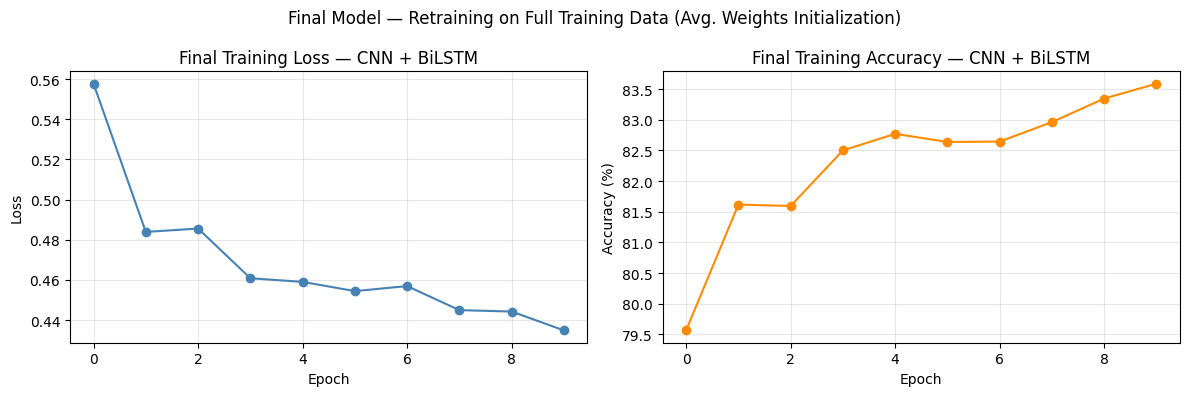


Evaluating on full training data (sanity check)...

Training Set Results — Final CNN + BiLSTM Model
Accuracy  : 84.00%
Macro F1  : 74.98%
Cohen's κ : 0.7759

              precision    recall  f1-score   support

           W       0.96      0.92      0.94     14961
          N1       0.58      0.29      0.39      4476
          N2       0.82      0.91      0.87     18659
          N3       0.94      0.60      0.73      3564
         REM       0.73      0.93      0.82      7490

    accuracy                           0.84     49150
   macro avg       0.81      0.73      0.75     49150
weighted avg       0.84      0.84      0.83     49150



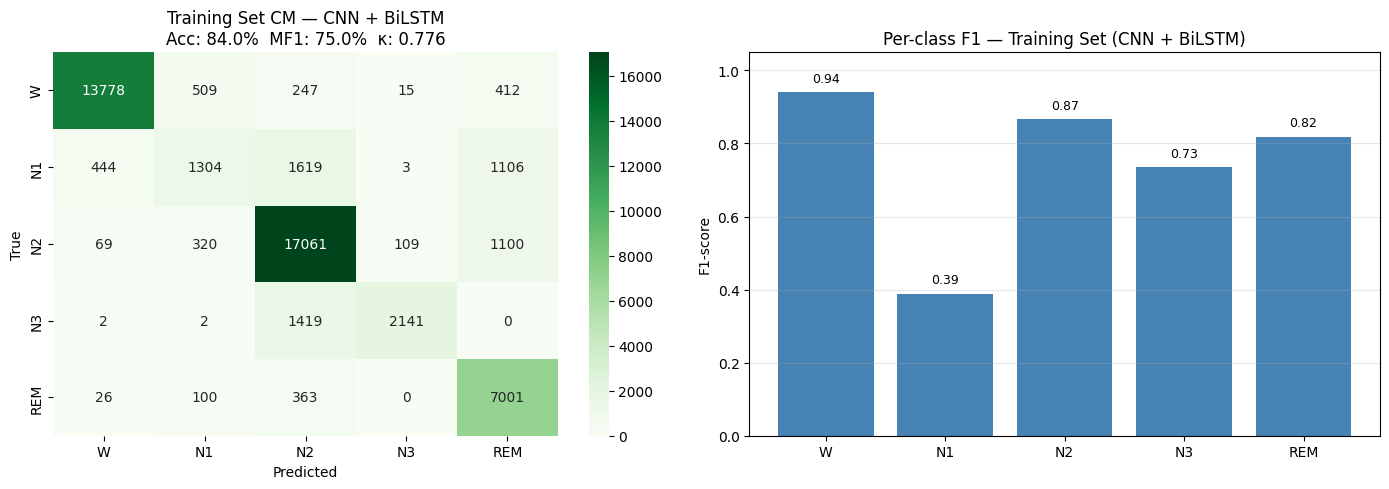

In [ ]:
# Step 1: Average weights across all 5 fold models
print("Averaging weights across all 5 fold models...")
avg_state = {}
for key in seq_fold_results[0]['state_dict'].keys():
    avg_state[key] = torch.stack(
        [seq_fold_results[i]['state_dict'][key].float() for i in range(N_FOLDS)]
    ).mean(dim=0)

final_seq_model = DeepSleepNet().to(DEVICE)
final_seq_model.load_state_dict(avg_state)
print("Averaged weights loaded ✓")

# Step 2: Retrain on ALL training sequences
print(f"\nRetraining on full training data ({len(X_train_seq):,} sequences)...")

full_seq_dataset = SeqSleepDataset(X_train_seq, y_train_seq)
full_seq_loader  = DataLoader(full_seq_dataset, batch_size=16,
                               shuffle=True, pin_memory=True)

cnn_params_f  = (list(final_seq_model.cnn_small.parameters()) +
                 list(final_seq_model.cnn_large.parameters()))
lstm_params_f = (list(final_seq_model.bilstm1.parameters())   +
                 list(final_seq_model.bilstm2.parameters())   +
                 list(final_seq_model.shortcut.parameters())  +
                 list(final_seq_model.classifier.parameters()))

optimizer_final = torch.optim.Adam([
    {'params': cnn_params_f,  'lr': 1e-6},
    {'params': lstm_params_f, 'lr': 1e-4},
])
criterion      = nn.CrossEntropyLoss()
N_FINAL_EPOCHS = 10
final_history  = {'train_loss': [], 'train_acc': []}

for epoch in range(1, N_FINAL_EPOCHS + 1):
    final_seq_model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_b, y_b in full_seq_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_final.zero_grad()
        out      = final_seq_model(X_b)
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        loss     = criterion(out_flat, y_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_seq_model.parameters(), max_norm=10)
        optimizer_final.step()
        total_loss += loss.item()
        correct    += (out_flat.argmax(1) == y_flat).sum().item()
        total      += len(y_flat)

    train_loss = total_loss / len(full_seq_loader)
    train_acc  = 100 * correct / total
    final_history['train_loss'].append(train_loss)
    final_history['train_acc'].append(train_acc)
    print(f"  Epoch {epoch:2d}/{N_FINAL_EPOCHS} | "
          f"Loss: {train_loss:.4f} | Acc: {train_acc:.1f}%")

final_seq_model_path = os.path.join(PROCESSED_DIR, "bilstm_final_model.pth")
torch.save(final_seq_model.state_dict(), final_seq_model_path)
print(f"\nFinal model saved → bilstm_final_model.pth")

# Step 3: Final training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(final_history['train_loss'], color='steelblue', marker='o')
ax1.set_title('Final Training Loss — CNN + BiLSTM')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(final_history['train_acc'], color='darkorange', marker='o')
ax2.set_title('Final Training Accuracy — CNN + BiLSTM')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(alpha=0.3)

fig.suptitle('Final Model — Retraining on Full Training Data '
             '(Avg. Weights Initialization)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 4: Training set evaluation
print("\nEvaluating on full training data (sanity check)...")
final_seq_model.eval()
tr_preds, tr_true = [], []
with torch.no_grad():
    for X_b, y_b in full_seq_loader:
        out      = final_seq_model(X_b.to(DEVICE))
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        tr_preds.extend(out_flat.argmax(1).cpu().numpy())
        tr_true.extend(y_flat.cpu().numpy())

tr_pred = np.array(tr_preds)
tr_true = np.array(tr_true)

tr_acc   = 100 * (tr_pred == tr_true).mean()
tr_mf1   = f1_score(tr_true, tr_pred, average='macro') * 100
tr_kappa = cohen_kappa_score(tr_true, tr_pred)
tr_f1_pc = f1_score(tr_true, tr_pred, average=None, labels=list(range(5)))
tr_cm    = confusion_matrix(tr_true, tr_pred)

print(f"\nTraining Set Results — Final CNN + BiLSTM Model")
print(f"{'='*50}")
print(f"Accuracy  : {tr_acc:.2f}%")
print(f"Macro F1  : {tr_mf1:.2f}%")
print(f"Cohen's κ : {tr_kappa:.4f}")
print()
print(classification_report(tr_true, tr_pred, target_names=stage_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(tr_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_title(f"Training Set CM — CNN + BiLSTM\n"
              f"Acc: {tr_acc:.1f}%  MF1: {tr_mf1:.1f}%  κ: {tr_kappa:.3f}")

bars = ax2.bar(stage_names, tr_f1_pc, color='steelblue')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1 — Training Set (CNN + BiLSTM)')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tr_f1_pc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Test Evaluation

Final CNN + BiLSTM model loaded for test evaluation ✓
Test sequences: 1,228

Test Results — Final CNN + BiLSTM Model
Accuracy  : 83.30%
Macro F1  : 76.18%
Cohen's κ : 0.7650

              precision    recall  f1-score   support

           W       0.95      0.83      0.89      5138
          N1       0.40      0.33      0.36      2225
          N2       0.85      0.91      0.88     13494
          N3       0.96      0.77      0.85      4152
         REM       0.77      0.90      0.83      5691

    accuracy                           0.83     30700
   macro avg       0.79      0.75      0.76     30700
weighted avg       0.83      0.83      0.83     30700



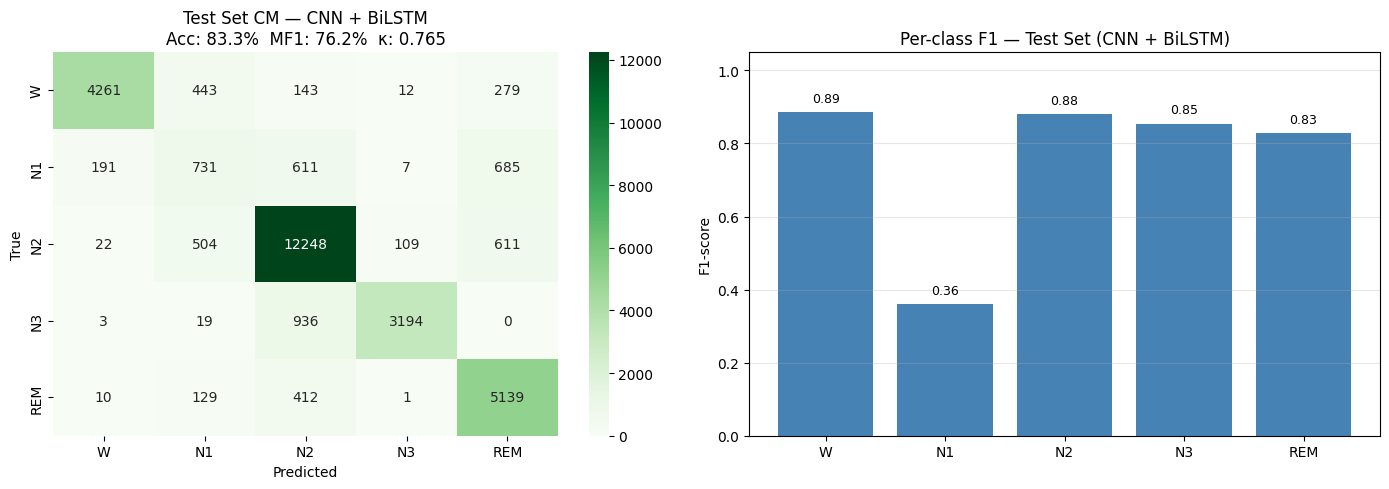

In [ ]:
final_seq_model.load_state_dict(
    torch.load(final_seq_model_path, map_location=DEVICE, weights_only=True)
)
final_seq_model.eval()
print("Final CNN + BiLSTM model loaded for test evaluation ✓")

test_seq_dataset = SeqSleepDataset(X_test_seq, y_test_seq)
test_seq_loader  = DataLoader(test_seq_dataset, batch_size=32,
                               shuffle=False, pin_memory=True)
print(f"Test sequences: {len(test_seq_dataset):,}")

all_preds, all_true = [], []
with torch.no_grad():
    for X_b, y_b in test_seq_loader:
        out      = final_seq_model(X_b.to(DEVICE))
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        all_preds.extend(out_flat.argmax(1).cpu().numpy())
        all_true.extend(y_flat.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_true)

acc          = 100 * (y_pred == y_true).mean()
mf1          = f1_score(y_true, y_pred, average='macro') * 100
kappa        = cohen_kappa_score(y_true, y_pred)
f1_per_class = f1_score(y_true, y_pred, average=None, labels=list(range(5)))
cm           = confusion_matrix(y_true, y_pred)

print(f"\nTest Results — Final CNN + BiLSTM Model")
print(f"{'='*50}")
print(f"Accuracy  : {acc:.2f}%")
print(f"Macro F1  : {mf1:.2f}%")
print(f"Cohen's κ : {kappa:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=stage_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_title(f"Test Set CM — CNN + BiLSTM\n"
              f"Acc: {acc:.1f}%  MF1: {mf1:.1f}%  κ: {kappa:.3f}")

bars = ax2.bar(stage_names, f1_per_class, color='steelblue')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1 — Test Set (CNN + BiLSTM)')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1_per_class):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()